<a href="https://colab.research.google.com/github/changsin/polysemy_xlang_wsi/blob/main/notebooks/polysemy_wsi_niv_cuv_mwe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Measuring Polysemy Across Languages
Polysemy, the capacity of a word to have more than one sense, is fundamental to natural language. This project uses WSI (Word Sense Induction) to compare and analyze polysemy across languages, starting from English and Chinese.

Before running, you need to upload english_verses.txt and chinese_verses.txt files under bible_data folder.

A verses file contains Bible verses with their book, chapter, and verse number in CSV format like the following.
```
verse_id,text
Gen.1.1,In the beginning God created the heavens and the earth.
```


## Steps
**Step 0: Install dependencies**

**Step 1: Corpus Preparation** (done outside of the notebook) Parses plain-text Bible files to output `language_verses.txt` file with the format: verse_id, text

**Step 2: Preprocessing - Extract Common Nouns** Process English and Chinese corpora to extract common nouns using spaCy (English) and jieba (Chinese) to tokenize, POS-tag, and lemmatize words.

**Step 3: Extract Context Embeddings** Generate contextual embeddings for each noun occurence using a pre-trained multilingual transformer model (XML-RoBERTa-base).

**Step 4: WSI Clustering** Apply HDBSCAN clustering to the extracted contextual embeddings and identify word senses based on the identified clusters.

**Step 5: Validation and Statistical Analysis** Validate the induced senses against WordNet and run statistical comparison of the two languages (e.g., Mann-Whitney U test)

**Step 6: Qualitative Analysis** Create a qualitative report of the most polysemous words, example contexts for each induced sense.


# Step 0. Install dependencies

In [ ]:
!pip install torch transformers scikit-learn numpy pandas --break-system-packages

In [ ]:
!pip install scipy matplotlib seaborn

In [ ]:
!pip install nltk spacy jieba hdbscan

In [ ]:
!python -m spacy download en_core_web_sm
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 62.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# Step 2. Preprocessing: Extract Common Nouns

In [ ]:
import json
import re
import pandas as pd
from pathlib import Path
from collections import Counter

# ─── Configuration ────────────────────────────────────────────────────────────

DATA_DIR = Path("/content") / "bible_data"
MIN_FREQ = 30          # Minimum occurrences per lemma for WSI
MAX_CONTEXT_LEN = 512  # Characters — prevents overlong inputs to transformers


# ─── Frequency Filtering ──────────────────────────────────────────────────────


def apply_frequency_filter(df: pd.DataFrame, min_freq: int = MIN_FREQ) -> tuple:
    """
    Keep only lemmas appearing at least `min_freq` times.
    Returns (filtered_df, freq_df).
    """
    freq = df.groupby("lemma").size().reset_index(name="count")
    freq = freq.sort_values("count", ascending=False)
    valid_lemmas = set(freq[freq["count"] >= min_freq]["lemma"])
    filtered = df[df["lemma"].isin(valid_lemmas)].copy()
    return filtered, freq

In [ ]:
KJV_ARCHAIC_EXCLUDE_FILE = DATA_DIR / "kjv_archaic_exclude.json"
# ZH_STOPWORDS_FILE = DATA_DIR / "chinese_stopwords.json"

EN_THEOLOGICAL_EXCLUDE = {
    # Lemma-level backstop for cases where spaCy tags as NOUN not PROPN
    "spirit",    # "Holy Spirit" — spaCy inconsistently tags as NOUN
    "ghost",     # "Holy Ghost" (KJV form; rare in NIV but present)
}

def _load_set_from_json(file_path: Path) -> set:
    """Loads a set of strings from a JSON file."""
    if not file_path.exists():
        print(f"WARNING: Exclusion file not found at {file_path}. Returning empty set.", flush=True)
        return set()
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise TypeError(f"Expected JSON file at {file_path} to contain a list, but got {type(data)}")
    return set(data)

# KJV-specific: exclude archaic pronouns/verbs mis-tagged as nouns
KJV_ARCHAIC_EXCLUDE = _load_set_from_json(KJV_ARCHAIC_EXCLUDE_FILE)


# ─── English Preprocessing ────────────────────────────────────────────────────

def preprocess_english(verse_csv: Path) -> pd.DataFrame:
    """
    Process English verses with spaCy.
    Returns long-format DataFrame: one row per noun occurrence.
    """
    try:
        import spacy
    except ImportError:
        raise ImportError("Run: pip install spacy --break-system-packages && python -m spacy download en_core_web_sm")

    print("  [EN] Loading spaCy model…")
    nlp = spacy.load("en_core_web_sm", disable=["ner", "textcat"])

    df = pd.read_csv(verse_csv)
    print(f"  [EN] Processing {len(df):,} verses…")

    import time
    records   = []
    texts     = df["text"].tolist()
    verse_ids = df["verse_id"].tolist()
    total     = len(texts)
    t0        = time.time()

    for i, (doc, vid) in enumerate(zip(nlp.pipe(texts, batch_size=512), verse_ids), 1):
        context = doc.text[:MAX_CONTEXT_LEN]
        for token in doc:
            # Keep only common nouns; exclude proper nouns and pronouns
            if (
                token.pos_ == "NOUN"
                and not token.is_stop
                and not token.is_punct
                and len(token.lemma_) > 1
                and token.lemma_.isalpha()
                and token.lemma_.lower() not in EN_THEOLOGICAL_EXCLUDE
                ## for KJV processing-only
                and token.lemma_.lower() not in KJV_ARCHAIC_EXCLUDE
            ):
                records.append({
                    "verse_id": vid,
                    "token":    token.text,
                    "lemma":    token.lemma_.lower(),
                    "context":  context,
                })

        # report the progress
        if i % 1000 == 0 or i == total:
            elapsed = time.time() - t0
            rate    = i / elapsed if elapsed > 0 else 0
            eta_min = (total - i) / rate / 60 if rate > 0 else 0
            print(f"    … {i:,}/{total:,} verses  "
                  f"({rate:.0f} v/s)  "
                  f"ETA {eta_min:.1f} min  "
                  f"nouns so far: {len(records):,}",
                  end="\r")

    elapsed_total = time.time() - t0
    print(f"\n  [EN] Done in {elapsed_total/60:.1f} min. "
          f"Extracted {len(records):,} noun occurrences.")
    return pd.DataFrame(records)

## Step 2.1: English Multi-Word Expression (MWE) Processing

To align the English preprocessing with the Chinese pipeline, which segments nominal compounds (e.g., 燔祭) as single lexical units, we introduce a Multi-Word Expression (MWE) detection and merging step for English nouns. This process aims to identify common adjective-noun (ADJ+NOUN) or noun-noun (NOUN+NOUN) phrases that function as single conceptual units and treat them as such.

### How it works:
1.  **Candidate Extraction**: The text is scanned for adjacent ADJ+NOUN or NOUN+NOUN pairs.
2.  **Scoring**: Each candidate bigram is scored using Pointwise Mutual Information (PMI) and Normalized PMI (NPMI) to quantify its cohesiveness (how likely the words are to appear together by chance).
3.  **Selection**: Bigrams exceeding predefined frequency and NPMI thresholds are selected as MWEs.
4.  **Merging and Instance List Rebuilding**: In a second pass, selected MWEs are merged into single lexical units (e.g., 'burnt_offering'). Crucially, the individual constituent words of these MWEs (e.g., 'burnt', 'offering') are *removed* from the list of single-word noun instances if they participate in a merged MWE. This ensures that the MWE takes precedence over its parts.
5.  **Output**: The result is a refined list of noun occurrences (including MWEs) that feeds into the subsequent embedding and WSI stages.

In [ ]:
print("=" * 60)
print("Step 2: Preprocessing")
print("=" * 60)

# ── English ───────────────────────────────────────────────────
en_raw = preprocess_english(DATA_DIR / "english_verses.csv")
en_filtered, en_freq = apply_frequency_filter(en_raw)
en_filtered.to_csv(DATA_DIR / "english_nouns_single.csv", index=False, encoding="utf-8")
en_freq.to_csv(DATA_DIR / "english_noun_freq_single.csv", index=False, encoding="utf-8")
print(f"  [EN] {en_filtered['lemma'].nunique():,} lemmas ≥ {MIN_FREQ} occurrences retained.")

# ── Summary ───────────────────────────────────────────────────
print("\n── Preprocessing Summary ──")
print(f"  EN noun tokens (filtered) : {len(en_filtered):,}")
print(f"  EN unique lemmas          : {en_filtered['lemma'].nunique():,}")

print("\n  Top 10 English nouns:")
print(en_freq.head(10).to_string(index=False))

print("\n✓ Step 2 complete.\n")

Step 2: Preprocessing
  [EN] Loading spaCy model…
  [EN] Processing 31,088 verses…
    … 31,088/31,088 verses  (346 v/s)  ETA 0.0 min  nouns so far: 116,878
  [EN] Done in 1.5 min. Extracted 116,878 noun occurrences.
  [EN] 636 lemmas ≥ 30 occurrences retained.

── Preprocessing Summary ──
  EN noun tokens (filtered) : 98,195
  EN unique lemmas          : 636

  Top 10 English nouns:
   lemma  count
     man   3927
     son   2929
    king   2533
  people   2376
     day   2037
    land   1501
    hand   1296
  father   1289
   house   1054
offering   1026

✓ Step 2 complete.



In [ ]:
import csv
import math
from collections import Counter, defaultdict

# ─── MWE Configuration ────────────────────────────────────────────────────────

# POS patterns treated as MWE candidates.
# NOTE: in biblical English, participial modifiers ("burnt", "molten",
# "graven") are frequently tagged VERB rather than ADJ by en_core_web_sm.
# Adding VERB+NOUN increases recall but also noise.
MWE_PATTERNS = [("ADJ", "NOUN"), ("NOUN", "NOUN")]
MWE_MIN_COUNT = 5  # Min bigram count to merge (5 = faithful mirror of Chinese)
MIN_NPMI = 0.40      # Minimum Normalized PMI for MWE selection
MIN_PMI = 0.0        # Minimum PMI for MWE selection
INCLUDE_VERB_NOUN = True # Set to True to include VERB+NOUN patterns

# Dependency labels admitted for the first token when ("VERB", "NOUN") is
# enabled. A participle that modifies the following noun attaches as amod
# (occasionally compound); a light verb's noun attaches to the verb as dobj,
# so the arc runs the other way and is rejected.
PARTICIPIAL_MODIFIER_DEPS = {"amod", "compound"}

# ─── Helper Functions (adapted from mwe_robustness.py) ──────────────────────

def parse_corpus(rows: list[tuple[str, str]], nlp, batch_size: int = 200):
    """Parse once, keep in memory. ~31k verses fits comfortably."""
    texts = [t for _, t in rows]
    ids = [v for v, _ in rows]
    docs = list(nlp.pipe(texts, batch_size=batch_size))
    return list(zip(ids, docs))

def norm_lemma(token) -> str:
    return token.lemma_.lower().strip()

def is_content_token(token, en_theological_exclude: set, kjv_archaic_exclude: set) -> bool:
    """Eligible to participate in an MWE or be counted as a unigram."""
    if not token.is_alpha:
        return False
    if token.is_stop or token.is_punct or token.is_space:
        return False
    if token.pos_ == "PROPN":          # keep proper names out entirely
        return False
    if norm_lemma(token) in en_theological_exclude:
        return False
    if norm_lemma(token) in kjv_archaic_exclude:
        return False
    return True

def is_target_noun(token, en_theological_exclude: set, kjv_archaic_exclude: set) -> bool:
    """A token that would be a lemma in the baseline pipeline."""
    return is_content_token(token, en_theological_exclude, kjv_archaic_exclude) and token.pos_ == "NOUN"

def bigram_ok(t1, t2, patterns) -> bool:
    """Contiguous, same sentence, no intervening punctuation, matching POS.
    Includes dependency parsing logic for VERB+NOUN to distinguish participial modifiers from light verbs.
    """
    # Ensure t1 and t2 are content tokens
    if not (is_content_token(t1, set(), set()) and is_content_token(t2, set(), set())):
        return False
    # Must be contiguous
    if t2.i != t1.i + 1:
        return False
    # Must be in the same sentence
    if t2.is_sent_start:
        return False
    # Reject line/verse boundaries
    if "\n" in t1.whitespace_:
        return False

    # Check if the POS pattern is generally allowed
    if (t1.pos_, t2.pos_) not in patterns:
        return False

    # Specific check for VERB+NOUN patterns: only allow participial modifiers
    if t1.pos_ == "VERB" and t2.pos_ == "NOUN":
        # The verb must attach to the following noun as an adjectival modifier
        # Check dependency relation and if t1's head is t2
        if t1.dep_ not in PARTICIPIAL_MODIFIER_DEPS or t1.head.i != t2.i:
            return False

    return True

# ─── MWE Core Logic Functions ────────────────────────────────────────────────

def collect_counts(parsed_docs, patterns, en_theological_exclude: set, kjv_archaic_exclude: set):
    """Unigram content-token counts and candidate bigram counts."""
    unigrams = Counter()
    bigrams = Counter()
    noun_unigrams = Counter()

    for _, doc in parsed_docs:
        for token in doc:
            if is_content_token(token, en_theological_exclude, kjv_archaic_exclude):
                unigrams[norm_lemma(token)] += 1
            if is_target_noun(token, en_theological_exclude, kjv_archaic_exclude):
                noun_unigrams[norm_lemma(token)] += 1

        for i in range(len(doc) - 1):
            t1, t2 = doc[i], doc[i + 1]
            if bigram_ok(t1, t2, patterns):
                bigrams[(norm_lemma(t1), norm_lemma(t2))] += 1

    return unigrams, bigrams, noun_unigrams

def score_bigrams(unigrams: Counter, bigrams: Counter):
    """Scores bigrams using PMI and NPMI."""
    n_tokens = sum(unigrams.values())
    n_bigrams = sum(bigrams.values())
    if n_tokens == 0 or n_bigrams == 0:
        return {}

    scored = {}
    for (w1, w2), count in bigrams.items():
        p_joint = count / n_bigrams
        p1 = unigrams[w1] / n_tokens
        p2 = unigrams[w2] / n_tokens
        if p1 <= 0 or p2 <= 0:
            continue
        pmi = math.log2(p_joint / (p1 * p2))
        npmi = pmi / (-math.log2(p_joint)) if p_joint < 1 else 0.0
        scored[(w1, w2)] = {
            "count": count,
            "count_w1": unigrams[w1],
            "count_w2": unigrams[w2],
            "pmi": pmi,
            "npmi": npmi,
        }
    return scored

def select_mwes(scored, min_count: int, min_npmi: float, min_pmi: float):
    """Apply thresholds. Returns dict {(w1,w2): stats} of selected MWEs."""
    return {
        pair: s for pair, s in scored.items()
        if s["count"] >= min_count and s["npmi"] >= min_npmi and s["pmi"] >= min_pmi
    }

def build_instances_mwe(parsed_docs, selected_mwes, patterns, en_theological_exclude: set, kjv_archaic_exclude: set):
    """
    Builds a list of dictionaries, where each dictionary represents a noun occurrence
    (either a single noun or an MWE) suitable for a Pandas DataFrame.
    This version implements a 'replacement' logic for MWEs and their constituents:
    If an MWE is found, only the MWE is recorded; its constituent words are not.
    """
    records = []

    for verse_id, doc in parsed_docs:
        i = 0
        n = len(doc)
        while i < n:
            t1 = doc[i]
            consumed_by_mwe = False

            # Check for MWE first (looking ahead to t2)
            if i + 1 < n:
                t2 = doc[i + 1]
                if bigram_ok(t1, t2, patterns):
                    pair = (norm_lemma(t1), norm_lemma(t2))
                    if pair in selected_mwes:
                        mwe_lemma = f"{pair[0]}_{pair[1]}"
                        start = t1.idx
                        end = t2.idx + len(t2.text)
                        records.append({
                            "verse_id": verse_id,
                            "token": doc.text[start:end], # Surface form of MWE
                            "lemma": mwe_lemma,
                            "context": doc.text[:MAX_CONTEXT_LEN], # Truncate context
                        })
                        i += 2 # Advance past both tokens if MWE is found
                        consumed_by_mwe = True

            # If t1 was not part of an MWE (or it was the last token),
            # then process it as a potential single word.
            if not consumed_by_mwe:
                if is_target_noun(t1, en_theological_exclude, kjv_archaic_exclude):
                    lemma = norm_lemma(t1)
                    records.append({
                        "verse_id": verse_id,
                        "token": t1.text,
                        "lemma": lemma,
                        "context": doc.text[:MAX_CONTEXT_LEN],
                    })
                i += 1 # Advance past t1 if no MWE was formed starting with it

    return records

# ─── New MWE-aware English Preprocessing Function ───────────────────────────

def preprocess_english_mwe(verse_csv: Path, en_theological_exclude: set, kjv_archaic_exclude: set) -> tuple[pd.DataFrame, dict, dict]:
    """
    Process English verses with spaCy, including MWE detection and merging.
    Returns long-format DataFrame: one row per noun occurrence (single or MWE).
    Also returns the dictionary of selected MWEs and *all* scored bigrams.
    """
    try:
        import spacy
    except ImportError:
        raise ImportError("Run: pip install spacy --break-system-packages && python -c \"import spacy; spacy.download('en_core_web_sm')\"")

    print("  [EN-MWE] Loading spaCy model…")
    nlp = spacy.load("en_core_web_sm", disable=["ner", "textcat"])

    df = pd.read_csv(verse_csv)
    print(f"  [EN-MWE] Processing {len(df):,} verses…")

    rows_for_parsing = df[["verse_id", "text"]].values.tolist()
    parsed_docs = parse_corpus(rows_for_parsing, nlp)

    # Configure patterns for MWE detection
    patterns_to_use = list(MWE_PATTERNS)
    if INCLUDE_VERB_NOUN:
        patterns_to_use.append(("VERB", "NOUN"))

    print("  [EN-MWE] Collecting counts for MWE detection...")
    unigrams, bigrams, noun_unigrams = collect_counts(
        parsed_docs, patterns_to_use, en_theological_exclude, kjv_archaic_exclude
    )
    print("  [EN-MWE] Scoring bigrams...")
    scored_bigrams = score_bigrams(unigrams, bigrams)
    print(f"  [EN-MWE] Found {len(scored_bigrams):,} candidate MWEs.")

    print("  [EN-MWE] Selecting MWEs based on thresholds...")
    selected_mwes = select_mwes(scored_bigrams, MWE_MIN_COUNT, MIN_NPMI, MIN_PMI)
    print(f"  [EN-MWE] {len(selected_mwes):,} MWEs selected (count>={MWE_MIN_COUNT}, npmi>={MIN_NPMI}).")

    print("  [EN-MWE] Merging MWEs and rebuilding instance list...")
    records = build_instances_mwe(
        parsed_docs, selected_mwes, patterns_to_use, en_theological_exclude, kjv_archaic_exclude
    )

    print(f"  [EN-MWE] Done. Extracted {len(records):,} noun/MWE occurrences.")
    return pd.DataFrame(records), selected_mwes, scored_bigrams

In [ ]:
import json
from pathlib import Path

KJV_ARCHAIC_EXCLUDE_FILE = DATA_DIR / "kjv_archaic_exclude.json"

EN_THEOLOGICAL_EXCLUDE = {
    "spirit",    # "Holy Spirit" — spaCy inconsistently tags as NOUN
    "ghost",     # "Holy Ghost" (KJV form; rare in NIV but present)
}

def _load_set_from_json(file_path: Path) -> set:
    """Loads a set of strings from a JSON file."""
    if not file_path.exists():
        print(f"WARNING: Exclusion file not found at {file_path}. Returning empty set.", flush=True)
        return set()
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise TypeError(f"Expected JSON file at {file_path} to contain a list, but got {type(data)}")
    return set(data)

KJV_ARCHAIC_EXCLUDE = _load_set_from_json(KJV_ARCHAIC_EXCLUDE_FILE)


print("=" * 60)
print("Step 2: Preprocessing (English with MWEs)")
print("=" * 60)

# ── English (with MWEs) ────────────────────────────────────────────────
# KJV_ARCHAIC_EXCLUDE and EN_THEOLOGICAL_EXCLUDE are defined in ZLqcvi0f1Mkn
# Use the new preprocess_english_mwe function
en_raw_mwe, selected_mwes_dict, all_scored_bigrams = preprocess_english_mwe(DATA_DIR / "english_verses.csv", EN_THEOLOGICAL_EXCLUDE, KJV_ARCHAIC_EXCLUDE)
en_filtered_mwe, en_freq_mwe = apply_frequency_filter(en_raw_mwe)
en_filtered_mwe.to_csv(DATA_DIR / "english_nouns.csv", index=False, encoding="utf-8")
en_freq_mwe.to_csv(DATA_DIR / "english_noun_freq.csv", index=False, encoding="utf-8")
print(f"  [EN-MWE] {en_filtered_mwe['lemma'].nunique():,} lemmas \u2265 {MIN_FREQ} occurrences retained.")

# ── Display MWEs ────────────────────────────────────────────────────────
print("\n── Extracted MWEs ──")
mwes_df = pd.DataFrame([
    {'mwe': '_'.join(pair), 'count': stats['count'], 'npmi': stats['npmi'], 'pmi': stats['pmi']}
    for pair, stats in selected_mwes_dict.items()
])
mwes_df = mwes_df.sort_values(by='count', ascending=False).reset_index(drop=True)
display(mwes_df.head(10))

# ── Summary ────────────────────────────────────────────────────────────
print("\n── Preprocessing Summary (English with MWEs) ──")
print(f"  EN noun/MWE tokens (filtered) : {len(en_filtered_mwe):,}")
print(f"  EN unique lemmas (single+MWE) : {en_filtered_mwe['lemma'].nunique():,}")

print("\n  Top 10 English nouns/MWEs:")
print(en_freq_mwe.head(10).to_string(index=False))

print("\u2713 Step 2 (English MWE) complete.\n")

Step 2: Preprocessing (English with MWEs)
  [EN-MWE] Loading spaCy model…
  [EN-MWE] Processing 31,088 verses…
  [EN-MWE] Collecting counts for MWE detection...
  [EN-MWE] Scoring bigrams...
  [EN-MWE] Found 5,636 candidate MWEs.
  [EN-MWE] Selecting MWEs based on thresholds...
  [EN-MWE] 519 MWEs selected (count>=5, npmi>=0.4).
  [EN-MWE] Merging MWEs and rebuilding instance list...
  [EN-MWE] Done. Extracted 115,567 noun/MWE occurrences.
  [EN-MWE] 648 lemmas ≥ 30 occurrences retained.

── Extracted MWEs ──


,mwe,count,npmi,pmi
0,burn_offering,274,1.864278,10.602172
1,grain_offering,134,1.614932,10.850653
2,sin_offering,120,1.307908,8.995993
3,young_man,114,1.197377,8.324347
4,right_hand,112,1.327103,9.260111
5,fellowship_offering,85,1.576903,11.630688
6,high_place,84,1.310652,9.689291
7,hill_country,83,1.655082,12.264167
8,high_priest,80,1.304660,9.736832
9,chief_priest,73,1.426002,10.830797



── Preprocessing Summary (English with MWEs) ──
  EN noun/MWE tokens (filtered) : 92,349
  EN unique lemmas (single+MWE) : 648

  Top 10 English nouns/MWEs:
 lemma  count
   man   3327
   son   2866
  king   2515
people   2350
   day   1871
  land   1446
father   1289
  hand   1122
 house   1043
  word    984
✓ Step 2 (English MWE) complete.



In [ ]:
en_freq_mwe.head(75)

,lemma,count
2392,man,3327
3702,son,2866
2179,king,2515
2858,people,2350
925,day,1871
...,...,...
3002,power,262
1351,family,259
1001,desert,259
882,cubit,257


In [ ]:
print(f"MIN_FREQ (minimum frequency threshold for WSI): {MIN_FREQ}")

# Check 'offering' in the filtered MWE-aware frequency dataframe
offering_in_filtered_mwe = en_freq_mwe[en_freq_mwe['lemma'] == 'offering']
if not offering_in_filtered_mwe.empty:
    print(f"'offering' in en_freq_mwe: {offering_in_filtered_mwe.iloc[0]['count']} occurrences")
else:
    print("'offering' is NOT present in en_freq_mwe (it was filtered out).")

# Let's inspect the frequency of 'offering' *before* the final frequency filter is applied to the MWE-aware data.
# We can do this by calculating the frequency from the `en_raw_mwe` DataFrame directly.
# This will show its actual count after MWEs have 'claimed' their instances, but before `MIN_FREQ` is applied.
raw_mwe_offering_count = en_raw_mwe[en_raw_mwe['lemma'] == 'offering'].shape[0]
print(f"Frequency of 'offering' in en_raw_mwe (before final MIN_FREQ filtering): {raw_mwe_offering_count}")

# Also, let's confirm the count of 'burn_offering'
burn_offering_count = en_freq_mwe[en_freq_mwe['lemma'] == 'burn_offering']
if not burn_offering_count.empty:
    print(f"'burn_offering' in en_freq_mwe: {burn_offering_count.iloc[0]['count']} occurrences")
else:
    print("'burn_offering' is NOT present in en_freq_mwe (it was filtered out).")

MIN_FREQ (minimum frequency threshold for WSI): 30
'offering' in en_freq_mwe: 254 occurrences
Frequency of 'offering' in en_raw_mwe (before final MIN_FREQ filtering): 254
'burn_offering' in en_freq_mwe: 274 occurrences


In [ ]:
print('\n── Detailed Lemma Count (MWE-Aware) ──')

# Get all unique lemmas/MWEs from the filtered MWE-aware dataframe
all_lemmas_mwe_set = set(en_filtered_mwe['lemma'].unique())
num_total_lemmas_mwe = len(all_lemmas_mwe_set)

# Get the MWE lemmas from the mwes_df (which already includes frequency filtering)
mwe_lemmas_set = set(mwes_df['mwe'])
num_mwes_identified = len(mwe_lemmas_set)

# Calculate the number of MWEs that actually passed the frequency filter
mwes_in_filtered_set = mwe_lemmas_set.intersection(all_lemmas_mwe_set)
num_mwes_filtered = len(mwes_in_filtered_set)

# Calculate single-word lemmas by removing MWEs (that passed filtering) from the total set
single_word_lemmas_mwe_set = all_lemmas_mwe_set - mwes_in_filtered_set
num_single_word_lemmas_mwe = len(single_word_lemmas_mwe_set)

print(f"Total unique lexical units (lemmas + MWEs) for WSI: {num_total_lemmas_mwe}")
print(f"  - Total MWEs identified (before frequency filtering): {num_mwes_identified}")
print(f"  - Number of MWEs (Multi-Word Expressions) after frequency filtering: {num_mwes_filtered}")
print(f"  - Number of single-word lemmas (after frequency filtering): {num_single_word_lemmas_mwe}")
print(f"Sum of filtered MWEs and single-word lemmas = {num_mwes_filtered} + {num_single_word_lemmas_mwe} = {num_mwes_filtered + num_single_word_lemmas_mwe}")

print("This breakdown confirms the total count includes both MWEs and single-word lemmas as distinct lexical types after frequency filtering.")


── Detailed Lemma Count (MWE-Aware) ──
Total unique lexical units (lemmas + MWEs) for WSI: 648
  - Total MWEs identified (before frequency filtering): 519
  - Number of MWEs (Multi-Word Expressions) after frequency filtering: 38
  - Number of single-word lemmas (after frequency filtering): 610
Sum of filtered MWEs and single-word lemmas = 38 + 610 = 648
This breakdown confirms the total count includes both MWEs and single-word lemmas as distinct lexical types after frequency filtering.


# Step 3: Extract Context Embeddings

## 3.1 get_target_embedding()
The core function is `get_target_embedding().`
It extracts contextualized embeddings for specific target words within sentences using a pre-trained transformer model (like `xlm-roberta-base` in this notebook). This is a crucial step for Word Sense Induction (WSI) as it captures the meaning of a word based on its surrounding context.

Here's a step-by-step explanation:

1.  **Purpose**: The primary goal is to generate a numerical vector (embedding) for each occurrence of a target word in a sentence. This vector represents the word's meaning in that particular context.

2.  **Inputs**: It takes a list of `sentences` and a corresponding list of `target_words`. The `tokenizer` and `model` (pre-loaded `AutoTokenizer` and `AutoModel` from `transformers`) are also passed as arguments.

3.  **Batch Processing**: To efficiently process a large number of sentences, the function uses mini-batches (defined by `BATCH_SIZE`). This allows for parallel computation on the GPU (if available).

4.  **Tokenization**: For each batch, sentences are tokenized using the `tokenizer`. This converts raw text into numerical `input_ids` that the model understands. Crucially, `return_offsets_mapping=True` is used to map the subword tokens back to their original character positions in the text, which helps in identifying the target word's tokens later.

5.  **Model Inference**: The tokenized inputs are fed into the `model` to get its hidden states. The `outputs.hidden_states` contain the activations from all layers of the transformer model.

6.  **Embedding Extraction from Layers**: Standard WSI practice often involves averaging embeddings from the last few layers of a transformer. In this function, the `LAYERS` variable (e.g., `[-1, -2, -3, -4]`) specifies which layers to consider. The hidden states from these selected layers are stacked and then averaged (`.mean(dim=0)`) to get a single contextual representation for each token in the sentence.

7.  **Target Word Subword Alignment**: The helper function `_find_subword_positions()` is used to locate the subword tokens that correspond to the `target_word` within the tokenized sentence. This is important because a single word might be split into multiple subword tokens by the tokenizer (e.g., "embedding" -> "em", "##bedd", "##ing").

8.  **Mean-Pooling for Target Word**: If the `target_word` is found and consists of multiple subword tokens, their corresponding contextual embeddings (from the averaged layers) are mean-pooled to create a single embedding for the target word. If the target word isn't found (e.g., due to tokenization quirks), it falls back to mean-pooling the entire sentence's non-special tokens.

9.  **L2 Normalization**: Finally, all extracted embeddings are L2 normalized. This is a common practice in WSI and other NLP tasks, especially when using cosine similarity for distance calculations, as it ensures that the length of the vector does not influence the similarity.

10. **Output**: The function returns a NumPy array (`np.ndarray`) where each row is the L2-normalized contextual embedding for a target word occurrence.

## 3.2 model inference output is embeddings

Context embeddings are extracted when the model inferences: i.e., `outputs = model(**encoded)`. It is important to note the role `torch.no_grad()` context manager plays when inferencing. Here's what it does:

1.  **Disables Gradient Calculation**: When you're training a neural network, PyTorch's autograd engine automatically tracks all operations on tensors that have `requires_grad=True`. This is necessary to compute gradients during the backward pass for optimization (e.g., using Stochastic Gradient Descent).

2.  **Why Disable it During Inference?**
    *   **Memory Efficiency**: Calculating and storing gradients requires significant memory. During inference, we don't need to update model weights, so these gradients are unnecessary. Disabling gradient calculation frees up GPU memory, allowing for larger batch sizes or processing larger models.
    *   **Speed**: The autograd engine adds computational overhead to track operations. By disabling it, computations can run faster as PyTorch doesn't need to build the computation graph.
    *   **Preventing Accidental Updates**: It ensures that no gradients are computed and, consequently, no model parameters are accidentally updated, which is crucial for maintaining a trained model's state during evaluation.

In summary, `with torch.no_grad():` tells PyTorch, "Hey, for everything inside this block, I don't need to compute gradients, so save memory and compute faster!" This is standard practice for evaluation, prediction, and embedding extraction tasks like the one in this notebook.

## 3.3 _find_subword_positions()
The _find_subword_positions() function serves a very specific and important purpose in the embedding extraction process. It acts as a utility to correctly identify the location of the target word's subword tokens within the full tokenized sentence.

Here's a breakdown:

Input: It takes two lists of integers:

sentence_ids: The list of token IDs for the entire sentence (including special tokens like [CLS] and [SEP]).
target_ids: The list of token IDs that represent the target word when tokenized in isolation.
The Problem it Solves: Transformer tokenizers (like the one used for XLM-RoBERTa) often break down words into smaller subword units (e.g., "embedding" might become "em", "##bedd", "##ing"). When we have a target word, we need to find exactly which of the sentence's subword tokens correspond to that target word, especially if the target word itself is a multi-subword unit.

How it Works: The function searches for target_ids as a contiguous subsequence within sentence_ids. It iterates through sentence_ids and checks if the target_ids sequence matches a slice of sentence_ids of the same length.

Output: If a match is found, it returns a list of integer indices representing the starting and ending positions of the target word's subword tokens within the sentence_ids. If no match is found (which can happen due to various tokenization edge cases or if the target word wasn't fully contained in the processed sentence length), it returns an empty list [].

Why it's important: Once these positions are identified, the get_target_embedding() function can then select the corresponding hidden states (contextual embeddings) from the model's output for only those specific subword tokens and mean-pool them to get a single, accurate contextual embedding for the entire target word.

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import time # Import time module for progress tracking
from pathlib import Path
from transformers import AutoTokenizer, AutoModel
from typing import List, Tuple

# ─── Configuration ────────────────────────────────────────────────────────────

DATA_DIR    = Path("/content") / "bible_data"
MODEL_NAME  = "xlm-roberta-base"   # Multilingual; same model for EN and ZH
BATCH_SIZE  = 32                   # Reduce to 8-16 if OOM on CPU
LAYERS      = [-1, -2, -3, -4]     # Last 4 layers averaged (standard WSI practice)
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
MAX_SEQ_LEN = 128                  # Max subword tokens per sentence

print(f"Using device: {DEVICE}")

# ─── Model Loading ────────────────────────────────────────────────────────────

def load_model():
    print(f"  [model] Loading {MODEL_NAME}…")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model     = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
    model.to(DEVICE)
    model.eval()
    return tokenizer, model


# ─── Embedding Extraction ─────────────────────────────────────────────────────

def get_target_embedding(
    tokenizer,
    model,
    sentences:  List[str],
    target_words: List[str],
) -> np.ndarray:
    """
    For each (sentence, target_word) pair, extract the contextual embedding
    of the target by:
      1. Tokenizing the sentence
      2. Finding subword token positions for the target word
      3. Averaging hidden states across the last 4 layers at those positions
      4. Mean-pooling across subwords for multi-token targets

    Returns: np.ndarray of shape (N, hidden_dim)
    """
    print(f"  Starting embedding extraction for {len(sentences):,} sentences...", flush=True)
    all_embeddings = []
    total_sentences = len(sentences)
    t0 = time.time()

    for i in range(0, total_sentences, BATCH_SIZE):
        batch_sents  = sentences[i : i + BATCH_SIZE]
        batch_targets = target_words[i : i + BATCH_SIZE]

        encoded = tokenizer(
            batch_sents,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_offsets_mapping=True,
        )
        offset_mappings = encoded.pop("offset_mapping")  # not passed to model

        encoded = {k: v.to(DEVICE) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)

        # Stack selected hidden layers: shape (n_layers, batch, seq_len, hidden)
        hidden_states = torch.stack(
            [outputs.hidden_states[l] for l in LAYERS], dim=0
        )
        # Mean over selected layers: (batch, seq_len, hidden)
        layer_mean = hidden_states.mean(dim=0).cpu().numpy()

        input_ids = encoded["input_ids"].cpu().numpy()

        for j, (target, offsets_j) in enumerate(zip(batch_targets, offset_mappings)):
            # Re-encode the target word alone to find its subword tokens
            target_enc = tokenizer.encode(
                target, add_special_tokens=False
            )
            # Find target subword positions in the sentence encoding
            target_positions = _find_subword_positions(
                input_ids[j].tolist(), target_enc
            )
            if target_positions:
                token_emb = layer_mean[j][target_positions].mean(axis=0)
            else:
                # Fallback: mean-pool entire sequence (excluding [CLS]/[SEP])
                seq_len = (input_ids[j] != tokenizer.pad_token_id).sum()
                token_emb = layer_mean[j][1 : seq_len - 1].mean(axis=0)

            all_embeddings.append(token_emb)

        # Progress indicator (print every 1000 sentences or at the end)
        current_processed = i + len(batch_sents)
        if current_processed % 1000 == 0 or current_processed == total_sentences:
            elapsed_time = time.time() - t0
            rate = current_processed / elapsed_time if elapsed_time > 0 else 0
            eta_seconds = (total_sentences - current_processed) / rate if rate > 0 else 0
            eta_minutes = eta_seconds / 60
            print(f"    ... {current_processed:,}/{total_sentences:,} sentences "
                  f"({rate:.0f} s/s) "
                  f"ETA {eta_minutes:.1f} min ", flush=True)

    print(f"  Finished embedding extraction. Total {len(all_embeddings):,} embeddings.", flush=True)
    embeddings = np.array(all_embeddings, dtype=np.float32)
    # L2 normalize for cosine-based clustering
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    return embeddings / norms


def _find_subword_positions(
    sentence_ids: List[int], target_ids: List[int]
) -> List[int]:
    """Find the start position of `target_ids` as a subsequence in `sentence_ids`."""
    n, m = len(sentence_ids), len(target_ids)
    for start in range(n - m + 1):
        if sentence_ids[start : start + m] == target_ids:
            return list(range(start, start + m))
    return []


# ─── Per-language Pipeline ────────────────────────────────────────────────────

def extract_embeddings_for_language(
    lang: str,
    noun_csv: Path,
    tokenizer,
    model,
) -> None:
    """Load nouns, extract embeddings, and save as .npz."""
    out_path = DATA_DIR / f"{lang}_embeddings.npz"
    if out_path.exists():
        print(f"  [{lang.upper()}] Embeddings already exist — skipping.")
        return

    df = pd.read_csv(noun_csv)
    print(f"  [{lang.upper()}] Extracting embeddings for {len(df):,} noun occurrences…")

    embeddings = get_target_embedding(
        tokenizer,
        model,
        sentences    = df["context"].tolist(),
        target_words = df["token"].tolist(),
    )
    print()  # newline after progress indicator

    np.savez_compressed(
        out_path,
        embeddings = embeddings,
        lemmas     = df["lemma"].to_numpy(dtype=str),
        verse_ids  = df["verse_id"].to_numpy(dtype=str),
        tokens     = df["token"].to_numpy(dtype=str),
    )
    print(f"  [{lang.upper()}] Saved {embeddings.shape} embeddings → {out_path.name}")

Using device: cuda


In [ ]:
print("=" * 60)
print("Step 3: Contextual Embedding Extraction (XLM-R)")
print("=" * 60)

tokenizer, model = load_model()

extract_embeddings_for_language(
    "english",
    DATA_DIR / "english_nouns.csv",
    tokenizer, model,
)

print("\n✓ Step 3 complete.\n")


Step 3: Contextual Embedding Extraction (XLM-R)
  [model] Loading xlm-roberta-base…


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [ENGLISH] Extracting embeddings for 92,349 noun occurrences…
  Starting embedding extraction for 92,349 sentences...
    ... 4,000/92,349 sentences (313 s/s) ETA 4.7 min 
    ... 8,000/92,349 sentences (320 s/s) ETA 4.4 min 
    ... 12,000/92,349 sentences (313 s/s) ETA 4.3 min 
    ... 16,000/92,349 sentences (309 s/s) ETA 4.1 min 
    ... 20,000/92,349 sentences (298 s/s) ETA 4.0 min 
    ... 24,000/92,349 sentences (285 s/s) ETA 4.0 min 
    ... 28,000/92,349 sentences (268 s/s) ETA 4.0 min 
    ... 32,000/92,349 sentences (257 s/s) ETA 3.9 min 
    ... 36,000/92,349 sentences (251 s/s) ETA 3.7 min 
    ... 40,000/92,349 sentences (247 s/s) ETA 3.5 min 
    ... 44,000/92,349 sentences (247 s/s) ETA 3.3 min 
    ... 48,000/92,349 sentences (254 s/s) ETA 2.9 min 
    ... 52,000/92,349 sentences (261 s/s) ETA 2.6 min 
    ... 56,000/92,349 sentences (262 s/s) ETA 2.3 min 
    ... 60,000/92,349 sentences (259 s/s) ETA 2.1 min 
    ... 64,000/92,349 sentences (256 s/s) ETA 1.8 min 
   

# Step 4: WSI Clustering

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from typing import Tuple, Dict
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ─── Configuration ────────────────────────────────────────────────────────────

DATA_DIR      = Path("/content") / "bible_data"
RANDOM_STATE  = 42
# NEW: Make second_cluster_threshold configurable
SECOND_CLUSTER_THRESHOLD = 0.08 # If the second largest cluster is below this proportion, count as monosemous

# ─── HDBSCAN ──────────────────────────────────────────────

import hdbscan
from sklearn.decomposition import PCA

def induce_senses_hdbscan(embeddings: np.ndarray):
    n_samples, n_features = embeddings.shape

    if n_samples < 20:
        return 1, np.zeros(n_samples, dtype=int)

    # L2 normalize
    embeddings = normalize(embeddings)

    # Optional PCA only if large sample size
    if n_samples > 200:
        n_components = min(100, n_samples - 1, n_features)
        embeddings = PCA(
            n_components=n_components,
            random_state=RANDOM_STATE
        ).fit_transform(embeddings)
        embeddings = normalize(embeddings)

    # too conservative
    # min_cluster_size = max(8, int(0.05 * n_samples))
    # NEW: More liberal parameters
    min_cluster_size = max(6, int(0.03 * n_samples))  # 3% instead of 5%

    clusterer = hdbscan.HDBSCAN(
        metric="euclidean",
        min_cluster_size=min_cluster_size,
        min_samples=max(5, min_cluster_size // 2),
        cluster_selection_method="eom"
    )

    labels = clusterer.fit_predict(embeddings)

    clusters = set(labels)
    clusters.discard(-1)

    k = len(clusters)

    if k <= 1:
        return 1, np.zeros(n_samples, dtype=int)

    sizes = sorted([sum(labels == c) for c in clusters], reverse=True)

    # Use the configurable variable
    if sizes[1] / n_samples < SECOND_CLUSTER_THRESHOLD:  # ← Changed this line
        return 1, np.zeros(n_samples, dtype=int)

    return k, labels


# ─── Run WSI for entire language ──────────────────────────────────────────────

def run_wsi_for_language(lang: str):
    """
    L Load embeddings and run WSI for all lemmas in a language.
    Saves two files:
      1. {lang}_wsi_results.csv    - summary stats per lemma
      2. {lang}_sense_labels.csv   - cluster assignments per occurrence
    """
    embeddings_file = DATA_DIR / f"{lang}_embeddings.npz"
    nouns_file      = DATA_DIR / f"{lang}_nouns.csv"

    if not embeddings_file.exists():
        print(f"  [{lang.upper()}] ERROR: {embeddings_file.name} not found. Run Step 3 first.")
        return

    print(f"\n  [{lang.upper()}] Loading embeddings…")
    data = np.load(embeddings_file, allow_pickle=True)
    lemmas_array = data["lemmas"]
    embeddings   = data["embeddings"]
    verse_ids    = data["verse_ids"]
    unique_lemmas = np.unique(lemmas_array)

    print(f"  [{lang.upper()}] Running WSI for {len(unique_lemmas):,} lemmas…")

    results = []
    all_labels = []  # Collect per-instance labels for sense_labels.csv

    for i, lemma in enumerate(unique_lemmas):
        mask = (lemmas_array == lemma)
        lemma_embeds = embeddings[mask]
        lemma_vids   = verse_ids[mask]

        k_hdb, labels_hdb = induce_senses_hdbscan(lemma_embeds)

        results.append({
            "lemma": lemma,
            "n_instances": len(lemma_embeds),
            "k_hdbscan": k_hdb,
        })

        for vid, cluster in zip(lemma_vids, labels_hdb):
            all_labels.append({
                "lemma": lemma,
                "verse_id": vid,
                "cluster_hdbscan": int(cluster),
            })

        if (i + 1) % 50 == 0 or (i + 1) == len(unique_lemmas):
            print(f"    … {i + 1:,}/{len(unique_lemmas):,} lemmas", end="\r")


    # Save summary results
    df = pd.DataFrame(results)
    out_path = DATA_DIR / f"{lang}_wsi_results.csv"
    df.to_csv(out_path, index=False)
    print(f"\n  [{lang.upper()}] Saved: {out_path.name}")

    # Save per-instance cluster labels
    labels_df = pd.DataFrame(all_labels)
    labels_path = DATA_DIR / f"{lang}_sense_labels.csv"
    labels_df.to_csv(labels_path, index=False)
    print(f"  [{lang.upper()}] Saved: {labels_path.name}")

    print(f"  [{lang.upper()}] Mean k (HDBSCAN): {df['k_hdbscan'].mean():.2f}  "
      f"Median: {df['k_hdbscan'].median():.0f}  "
      f"Monosemous (k=1): {(df['k_hdbscan']==1).sum()} / {len(df)}")

In [ ]:
print("=" * 60)
print("Step 4: Word Sense Induction (WSI)")
print("=" * 60)

run_wsi_for_language("english")

# Quick comparison preview
en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")

print("\n── Quick Comparison Preview ──")
print(f"  EN | mean senses/lemma : {en['k_hdbscan'].mean():.3f}")
print(f"  EN | % polysemous lemmas       : {(en['k_hdbscan'] > 1).mean()*100:.1f}%")

print("\n✓ Step 4 complete.\n")

Step 4: Word Sense Induction (WSI)

  [ENGLISH] Loading embeddings…
  [ENGLISH] Running WSI for 648 lemmas…
    … 648/648 lemmas
  [ENGLISH] Saved: english_wsi_results.csv
  [ENGLISH] Saved: english_sense_labels.csv
  [ENGLISH] Mean k (HDBSCAN): 1.82  Median: 2  Monosemous (k=1): 281 / 648

── Quick Comparison Preview ──
  EN | mean senses/lemma : 1.818
  EN | % polysemous lemmas       : 56.6%

✓ Step 4 complete.



# Step 5: Validation and Statistical Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from typing import Optional, Tuple

# ─── Configuration ────────────────────────────────────────────────────────────

DATA_DIR    = Path("/content") / "bible_data"
OUTPUT_DIR = Path("/content") / "output"
FIG_DIR    = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family":  "DejaVu Sans",
    "font.size":    11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})


# ─── WordNet Validation (English) ────────────────────────────────────────────

def get_wordnet_sense_counts(lemmas: list) -> dict:
    """
    Look up the number of synsets for each lemma in Princeton WordNet.
    Noun synsets only (pos='n').
    """
    try:
        from nltk.corpus import wordnet as wn
    except ImportError:
        raise ImportError("Run: pip install nltk --break-system-packages && "
                          "python -c \"import nltk; nltk.download('wordnet')\"")

    counts = {}
    for lemma in lemmas:
        synsets = wn.synsets(lemma.lower(), pos=wn.NOUN)
        counts[lemma] = len(synsets)
    return counts


def validate_english(en_results: pd.DataFrame) -> pd.DataFrame:
    """
    Correlate WSI-induced k_ward with WordNet sense counts for English nouns.
    Returns a merged DataFrame with both counts.
    """
    print("  [validate] Looking up Princeton WordNet sense counts…")
    lemmas = en_results["lemma"].tolist()
    wn_counts = get_wordnet_sense_counts(lemmas)

    en_results = en_results.copy()
    en_results["wn_senses"] = en_results["lemma"].map(wn_counts).fillna(0).astype(int)

    # Keep only lemmas with at least 1 WordNet entry
    valid = en_results[en_results["wn_senses"] > 0].copy()

    rho, p = stats.spearmanr(valid["k_hdbscan"], valid["wn_senses"])
    print(f"  [validate] EN Spearman ρ(k_hdbscan, WN_senses) = {rho:.3f}  p = {p:.4f}  "
          f"(n={len(valid)})")

    return valid, rho, p


# ─── WordNet Validation (Chinese) ────────────────────────────────────────────

def get_chinese_wordnet_sense_counts(lemmas: list) -> dict:
    """
    Look up the number of synsets for each lemma in Chinese WordNet (cmn).
    Noun synsets only (pos='n').
    """
    try:
        from nltk.corpus import wordnet as wn
    except ImportError:
        raise ImportError("Run: pip install nltk --break-system-packages && "
                          "python -c \"import nltk; nltk.download('wordnet')\"")

    counts = {}
    for lemma in lemmas:
        # 'cmn' is the language code for Mandarin Chinese in WordNet
        # Note: Chinese WordNet coverage in NLTK might be limited compared to English
        synsets = wn.synsets(lemma, lang="cmn", pos=wn.NOUN)
        counts[lemma] = len(synsets)
    return counts


def validate_chinese(zh_results: pd.DataFrame) -> pd.DataFrame:
    """
    Correlate WSI-induced k_ward with Chinese WordNet sense counts for Chinese nouns.
    Returns a merged DataFrame with both counts.
    """
    print("  [validate] Looking up Chinese WordNet sense counts…")
    lemmas = zh_results["lemma"].tolist()
    cwn_counts = get_chinese_wordnet_sense_counts(lemmas)

    zh_results = zh_results.copy()
    zh_results["cwn_senses"] = zh_results["lemma"].map(cwn_counts).fillna(0).astype(int)

    # Keep only lemmas with at least 1 WordNet entry
    valid = zh_results[zh_results["cwn_senses"] > 0].copy()

    if len(valid) == 0:
        print("  [validate] No Chinese lemmas found in NLTK's Chinese WordNet. Skipping Spearman correlation.")
        rho, p = np.nan, np.nan # No correlation if no data
    elif len(valid) == 1:
        print("  [validate] Only one Chinese lemma found in NLTK's Chinese WordNet. Skipping Spearman correlation.")
        rho, p = np.nan, np.nan # Spearman requires at least two data points
    else:
        rho, p = stats.spearmanr(valid["k_hdbscan"], valid["cwn_senses"])
        print(f"  [validate] ZH Spearman ρ(k_hdbscan, CWN_senses) = {rho:.3f}  p = {p:.4f}  "
              f"(n={len(valid)})")

    return valid, rho, p


# ─── Statistical Comparison ──────────────────────────────────────────────────

def mann_whitney_comparison(
    en_k: np.ndarray,
    zh_k: np.ndarray,
) -> dict:
    """
    Mann-Whitney U test comparing mean sense counts between EN and ZH.
    Also computes Cohen's d and the common language effect size (CLES).
    """
    u_stat, p_val = stats.mannwhitneyu(en_k, zh_k, alternative="two-sided")
    n1, n2        = len(en_k), len(zh_k)
    cles          = u_stat / (n1 * n2)  # Common Language Effect Size

    # Cohen's d (for reference alongside CLES)
    pooled_std = np.sqrt(
        ((n1 - 1) * en_k.std(ddof=1) ** 2 + (n2 - 1) * zh_k.std(ddof=1) ** 2)
        / (n1 + n2 - 2)
    )
    cohens_d = (en_k.mean() - zh_k.mean()) / (pooled_std + 1e-9)

    return {
        "en_mean_k":   round(en_k.mean(), 4),
        "zh_mean_k":   round(zh_k.mean(), 4),
        "en_median_k": round(float(np.median(en_k)), 4),
        "zh_median_k": round(float(np.median(zh_k)), 4),
        "en_std_k":    round(en_k.std(ddof=1), 4),
        "zh_std_k":    round(zh_k.std(ddof=1), 4),
        "U_statistic": round(u_stat, 2),
        "p_value":     round(p_val, 6),
        "CLES":        round(cles, 4),
        "cohens_d":    round(cohens_d, 4),
        "n_en":        int(n1),
        "n_zh":        int(n2),
    }


# ─── Figures ─────────────────────────────────────────────────────────────────

def plot_sense_distribution(df: pd.DataFrame, lang: str, col: str = "k_hdbscan") -> None:
    fig, ax = plt.subplots(figsize=(8, 4))
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color="#4C72B0", edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Number of Induced Senses (k)")
    ax.set_ylabel("Number of Lemmas")
    ax.set_title(f"{lang.capitalize()} — Distribution of Induced Senses per Noun Lemma")
    ax.set_xticks(range(1, df[col].max() + 1))
    fig.tight_layout()
    path = FIG_DIR / f"sense_distribution_{lang}.png"
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"  [fig] Saved: {path.name}")


def plot_comparison_boxplot(en_df: pd.DataFrame, zh_df: pd.DataFrame) -> None:
    combined = pd.concat([
        en_df[["k_hdbscan"]].assign(Language="English"),
        zh_df[["k_hdbscan"]].assign(Language="Chinese"),
    ])
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.violinplot(data=combined, x="Language", y="k_hdbscan",
                   palette=["#4C72B0", "#DD8452"], inner="box",
                   cut=0,   # ← add this to fix sns artifact of extending beyond 8
                   ax=ax)
    ax.set_ylabel("Induced Senses per Lemma (k, Ward)")
    ax.set_title("Distribution of Polysemy Degree: English vs. Chinese Common Nouns\n"
                 "(Bible Parallel Corpus, WSI via XLM-R + Agglomerative Clustering)")
    fig.tight_layout()
    path = FIG_DIR / "comparison_violinplot.png"
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"  [fig] Saved: {path.name}")


def plot_wordnet_correlation(valid_df: pd.DataFrame, rho: float, p: float) -> None:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(valid_df["wn_senses"], valid_df["k_hdbscan"],
               alpha=0.4, s=20, color="#4C72B0")
    ax.set_xlabel("WordNet Noun Synset Count")
    ax.set_ylabel("WSI-Induced k (HDBSCAN)")
    ax.set_title(f"Validation: WSI k vs. WordNet Senses (English Nouns)\n"
                 f"Spearman ρ = {rho:.3f}, p = {p:.4f}")
    # Trend line
    m, b = np.polyfit(valid_df["wn_senses"], valid_df["k_hdbscan"], 1)
    x_line = np.linspace(valid_df["wn_senses"].min(), valid_df["wn_senses"].max(), 100)
    ax.plot(x_line, m * x_line + b, color="red", linewidth=1.5, linestyle="--")
    fig.tight_layout()
    path = FIG_DIR / "wordnet_correlation_en.png"
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"  [fig] Saved: {path.name}")

def plot_wordnet_correlation_chinese(valid_df: pd.DataFrame, rho: float, p: float) -> None:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(valid_df["cwn_senses"], valid_df["k_hdbscan"],
               alpha=0.4, s=20, color="#DD8452") # Using a different color for Chinese
    ax.set_xlabel("Chinese WordNet Noun Synset Count")
    ax.set_ylabel("WSI-Induced k (Ward)")
    ax.set_title(f"Validation: WSI k vs. Chinese WordNet Senses\n"
                 f"Spearman ρ = {rho:.3f}, p = {p:.4f}")
    # Trend line
    # Only plot trend line if there's enough data and correlation is valid
    if not np.isnan(rho) and len(valid_df) > 1:
        m, b = np.polyfit(valid_df["cwn_senses"], valid_df["k_hdbscan"], 1)
        x_line = np.linspace(valid_df["cwn_senses"].min(), valid_df["cwn_senses"].max(), 100)
        ax.plot(x_line, m * x_line + b, color="red", linewidth=1.5, linestyle="--")

    fig.tight_layout()
    path = FIG_DIR / "wordnet_correlation_zh.png"
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"  [fig] Saved: {path.name}")


In [ ]:
print("=" * 60)
print("Step 5: Validation and Statistical Analysis")
print("=" * 60)

en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# ── Validation (English vs. WordNet) ──────────────────────────
valid_en, rho_en, p_en = validate_english(en)
valid_en.to_csv(OUTPUT_DIR / "validation_correlation_en.csv", index=False)

# ── Validation (Chinese vs. WordNet) ──────────────────────────
valid_zh, rho_zh, p_zh = validate_chinese(zh)
valid_zh.to_csv(OUTPUT_DIR / "validation_correlation_zh.csv", index=False)

# ── Statistical Comparison ────────────────────────────────────
stats_result = mann_whitney_comparison(
    en["k_hdbscan"].values,
    zh["k_hdbscan"].values,
)
stats_df = pd.DataFrame([stats_result])
stats_df.to_csv(OUTPUT_DIR / "statistical_comparison.csv", index=False)

print("\n── Statistical Comparison Results ──")
for k, v in stats_result.items():
    print(f"  {k:22s}: {v}")

# ── Figures ───────────────────────────────────────────────────
plot_sense_distribution(en, "english")
plot_sense_distribution(zh, "chinese")
plot_comparison_boxplot(en, zh)
plot_wordnet_correlation(valid_en, rho_en, p_en)
# You might want to create a plot for Chinese WordNet correlation as well, if coverage is good
plot_wordnet_correlation_chinese(valid_zh, rho_zh, p_zh) # This would require a new function

# ── Interpretation ────────────────────────────────────────────
print("\n── Interpretation ──")
if stats_result["p_value"] < 0.05:
    direction = "English" if stats_result["en_mean_k"] > stats_result["zh_mean_k"] else "Chinese"
    print(f"  Significant difference found (p={stats_result['p_value']:.4f}).")
    print(f"  {direction} nouns show higher mean polysemy degree.")
else:
    print(f"  No significant difference found (p={stats_result['p_value']:.4f}).")

d = abs(stats_result["cohens_d"])
magnitude = "small" if d < 0.2 else ("medium" if d < 0.5 else "large")
print(f"  Effect size: Cohen's d = {stats_result['cohens_d']:.3f} ({magnitude})")
print(f"  Spearman ρ (EN WSI vs. WordNet): {rho_en:.3f} (p={p_en:.4f})")
print(f"  Spearman ρ (ZH WSI vs. WordNet): {rho_zh:.3f} (p={p_zh:.4f})")

print("\n✓ Step 5 complete.\n")

Step 5: Validation and Statistical Analysis
  [validate] Looking up Princeton WordNet sense counts…
  [validate] EN Spearman ρ(k_hdbscan, WN_senses) = 0.121  p = 0.0027  (n=613)
  [validate] Looking up Chinese WordNet sense counts…


/usr/local/lib/python3.12/dist-packages/nltk/corpus/reader/wordnet.py:2214: UserWarning: cmn: invalid offset 14869976-n in '14869976-n	cmn:lemma	污点
'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/nltk/corpus/reader/wordnet.py:2214: UserWarning: cmn: invalid offset 14869977-n in '14869977-n	cmn:lemma	小斑
'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/nltk/corpus/reader/wordnet.py:2214: UserWarning: cmn: invalid offset 15168570-n in '15168570-n	cmn:lemma	规定的睡觉时间
'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/nltk/corpus/reader/wordnet.py:2214: UserWarning: cmn: invalid offset 15171146-n in '15171146-n	cmn:lemma	节日
'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/nltk/corpus/reader/wordnet.py:2214: UserWarning: cmn: invalid offset 15171147-n in '15171147-n	cmn:lemma	纪念日
'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/nltk/corpus/reader/wordnet.py:2214: UserWarning: cmn: invalid offset 15171739-n in '15171739-n	cmn:lemma	竞技状态不佳的日子
'
  

  [validate] ZH Spearman ρ(k_hdbscan, CWN_senses) = 0.072  p = 0.4091  (n=134)

── Statistical Comparison Results ──
  en_mean_k             : 1.8179
  zh_mean_k             : 1.2319
  en_median_k           : 2.0
  zh_median_k           : 1.0
  en_std_k              : 1.0134
  zh_std_k              : 0.5437
  U_statistic           : 222840.5
  p_value               : 0.0
  CLES                  : 0.6933
  cohens_d              : 0.6955
  n_en                  : 648
  n_zh                  : 496
  [fig] Saved: sense_distribution_english.png
  [fig] Saved: sense_distribution_chinese.png
  [fig] Saved: comparison_violinplot.png
  [fig] Saved: wordnet_correlation_en.png
  [fig] Saved: wordnet_correlation_zh.png

── Interpretation ──
  Significant difference found (p=0.0000).
  English nouns show higher mean polysemy degree.
  Effect size: Cohen's d = 0.696 (large)
  Spearman ρ (EN WSI vs. WordNet): 0.121 (p=0.0027)
  Spearman ρ (ZH WSI vs. WordNet): 0.072 (p=0.4091)

✓ Step 5 complete.



## 5.1 WordNet Coverage

In [ ]:
import nltk
from nltk.corpus import wordnet as wn
import pandas as pd
from pathlib import Path

# Ensure the 'en' DataFrame is loaded, if not already in memory
# (assuming DATA_DIR is defined from previous cells)
if 'en' not in locals():
    DATA_DIR = Path("/content") / "bible_data"
    en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")

english_lemmas = en['lemma'].tolist()
n_with_synsets_en = sum(1 for lemma in english_lemmas
                          if len(wn.synsets(lemma.lower(), pos=wn.NOUN)) > 0)

total_lemmas_en = len(english_lemmas)
print(f"English WordNet Coverage: {n_with_synsets_en}/{total_lemmas_en} = {n_with_synsets_en/total_lemmas_en:.1%}")


English WordNet Coverage: 613/648 = 94.6%


In [ ]:
# Install necessary libraries if not already installed
!pip install pyclics --break-system-packages

In [ ]:
from pyclics.api import Clics

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# # Install necessary libraries if not already installed
# !pip install pyclics --break-system-packages

# Try to import Clics and handle potential data download
try:
    from pyclics.api import Clics, Database
except ImportError:
    print("pyclics not installed or Clics class not found. Please install with: !pip install pyclics --break-system-packages")
    clics_available = False
else:
    clics_available = True

# Configuration (using existing DATA_DIR from notebook context)
DATA_DIR = Path("/content") / "bible_data"
OUTPUT_DIR = Path("/content") / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True) # Ensure figures directory exists

# Load English WSI results
en_results = pd.read_csv(DATA_DIR / "english_wsi_results.csv")

print("--- Validating English Polysemy with CLICS Colexification Data ---")

if clics_available:
    # Define the path to the CLICS database
    db_path = Path("clics.sqlite") # Assumes clics.sqlite is in the current directory

    if not db_path.exists():
        print(f"CLICS database not found at {db_path}.")
        print("Please download the CLICS data by running the download cell, then restart the runtime and try again.")
        clics_data_loaded = False
    else:
        try:
            # CORRECTED: Initialize pyclics.api.Database directly
            clics_db = Database(fname=db_path)
            print(f"Successfully loaded CLICS database from: {db_path}")
            clics_data_loaded = True
        except Exception as e:
            print(f"An unexpected error occurred while loading CLICS: {e}")
            clics_data_loaded = False
else:
    clics_data_loaded = False


if clics_data_loaded:
    # --- Calculate CLICS-based polysemy ---
    # Build a dictionary for fast lookup of concepts by form name
    clics_form_concepts = defaultdict(set)
    try:
        # CORRECTED: Access forms through clics_db.iter_forms()
        print("Accessing forms from CLICS database.")
        for form in clics_db.iter_forms():
            form_name = form.name.lower() # Normalize to lowercase

            # Iterate over concepts associated with this form
            for concept in form.concepts:
                clics_form_concepts[form_name].add(concept.name)

        print(f"Pre-processed {len(clics_form_concepts):,} CLICS forms for concept lookup.")
    except Exception as e:
        print(f"ERROR: Failed to process CLICS forms: {e}")
        clics_data_loaded = False # Mark as failed if data processing hits an issue

if clics_data_loaded:
    lemma_clics_polysemy = {}
    for lemma in en_results['lemma'].unique():
        # Get concepts for the current lemma
        concepts = clics_form_concepts.get(lemma.lower(), set())
        lemma_clics_polysemy[lemma] = len(concepts)

    # Merge CLICS polysemy with WSI results
    clics_poly_df = pd.DataFrame(
        list(lemma_clics_polysemy.items()),
        columns=['lemma', 'clics_polysemy_score']
    )

    merged_df = en_results.merge(clics_poly_df, on='lemma', how='left')
    merged_df['clics_polysemy_score'] = merged_df['clics_polysemy_score'].fillna(0).astype(int)

    print(f"Number of English lemmas in WSI results with corresponding CLICS polysemy data: {len(merged_df[merged_df['clics_polysemy_score'] > 0])}")

    # --- Correlation Analysis ---
    # Filter for lemmas that have at least one WSI sense (k>0) and at least one CLICS concept (score>0)
    valid_for_correlation = merged_df[(merged_df['k_hdbscan'] > 0) & (merged_df['clics_polysemy_score'] > 0)]

    if len(valid_for_correlation) > 1:
        rho, p = stats.spearmanr(
            valid_for_correlation['k_hdbscan'],
            valid_for_correlation['clics_polysemy_score']
        )
        print(f"--- Correlation Results (WSI k vs. CLICS Polysemy Score) ---")
        print(f"Spearman \u03c1 = {rho:.3f}")
        print(f"P-value    = {p:.4f}")
        print(f"N (lemmas with both non-zero scores) = {len(valid_for_correlation)}")

        # --- Visualization ---
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=valid_for_correlation,
            x='clics_polysemy_score',
            y='k_hdbscan',
            alpha=0.6,
            s=50,
            color='#4C72B0'
        )
        plt.title('WSI-Induced k vs. CLICS Colexification Polysemy (English Lemmas)')
        plt.xlabel('CLICS Colexification Polysemy Score (Number of Concepts)')
        plt.ylabel('WSI-Induced Senses (k_hdbscan)')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()

        plot_filename = FIGURES_DIR / "wsi_clics_polysemy_correlation.png"
        plt.savefig(plot_filename, dpi=300)
        print(f"\nSaved correlation plot to {plot_filename}")
        plt.show()
    else:
        print("\nNot enough data points (lemmas with non-zero WSI k and CLICS polysemy) to compute correlation or plot.")

else:
    print("\nSkipping CLICS validation due to dataset loading or processing issues.")

--- Validating English Polysemy with CLICS Colexification Data ---
Successfully loaded CLICS dataset from: clics.sqlite
Accessing forms from CLICS dataset.
ERROR: Failed to process CLICS forms: 'Clics' object has no attribute 'forms'

Skipping CLICS validation due to dataset loading or processing issues.


In [ ]:
import os
from pathlib import Path

CLICS_DB_PATH = Path("clics.sqlite")

if not CLICS_DB_PATH.exists():
    print(f"'{CLICS_DB_PATH}' not found. Attempting to download CLICS database (clics-4.0.zip). This may take a few minutes...")
    # Downloading clics-4.0.zip directly from the official CLICS website
    !wget https://clics.clld.org/download/clics-4.0.zip -O clics-4.0.zip

    if os.path.exists("clics-4.0.zip") and os.path.getsize("clics-4.0.zip") > 0:
        print("CLICS database ZIP download complete. Extracting clics-4.0.sqlite...")
        # Unzip in current directory, overwrite if exists
        !unzip -o clics-4.0.zip

        # Assuming the sqlite file inside is named 'clics-4.0.sqlite'
        # Check if clics-4.0.sqlite exists and rename it to clics.sqlite
        if os.path.exists("clics-4.0.sqlite"):
            os.rename("clics-4.0.sqlite", CLICS_DB_PATH)
            print(f"Renamed 'clics-4.0.sqlite' to '{CLICS_DB_PATH}'.")
            # Clean up the downloaded zip file
            os.remove("clics-4.0.zip")
            print("Cleaned up clics-4.0.zip.")
        else:
            print("Warning: 'clics-4.0.sqlite' not found after unzipping. Please check zip contents or the CLICS download page.")
    else:
        print("Error: clics-4.0.zip was not downloaded successfully or is empty. Cannot proceed with extraction.")
else:
    print(f"'{CLICS_DB_PATH}' already exists. Skipping download and extraction.")

# Final check for clics.sqlite
if CLICS_DB_PATH.exists():
    print(f"'{CLICS_DB_PATH}' is ready.")
    print("CLICS database preparation complete. Please restart the Colab runtime (Runtime > Restart runtime) and then proceed to the next cell to re-initialize CLICS.")
else:
    print(f"Error: '{CLICS_DB_PATH}' not found. Please check the download and extraction steps.")

'clics.sqlite' already exists. Skipping download and extraction.
'clics.sqlite' is ready.
CLICS database preparation complete. Please restart the Colab runtime (Runtime > Restart runtime) and then proceed to the next cell to re-initialize CLICS.


After restarting the runtime, re-run the cells from 'Step 0. Install dependencies' up to this point, then proceed. The next cell will now correctly initialize CLICS using the downloaded database.

In [ ]:
import inspect
import pyclics.api

print("Content of pyclics.api:")
for name, obj in inspect.getmembers(pyclics.api):
    if inspect.isclass(obj) or inspect.isfunction(obj):
        print(f"  - {name}")

print("\nAlso trying dir(pyclics.api):")
print(dir(pyclics.api))

Content of pyclics.api:
  - API
  - Clics
  - Database
  - Network
  - UnicodeWriter
  - getGlobalSiteManager
  - getUtility
  - iter_subgraphs
  - lazyproperty
  - register_clicsfom
  - register_clusterer
  - register_colexifier
  - tqdm

Also trying dir(pyclics.api):
['API', 'Clics', 'Database', 'Network', 'UnicodeWriter', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'collections', 'getGlobalSiteManager', 'getUtility', 'interfaces', 'iter_subgraphs', 'itertools', 'json', 'jsonlib', 'lazyproperty', 'plugin', 'register_clicsfom', 'register_clusterer', 'register_colexifier', 'tqdm']


In [ ]:
from pyclics.api import Clics
from pathlib import Path

# Initialize Clics with the path to the downloaded clics.sqlite file
clics = Clics(repos=Path("clics.sqlite"))
# from errors import CLICSError # This import was likely for custom error handling and is not part of pyclics by default.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Ensure OUTPUT_DIR and FIGURES_DIR are defined
OUTPUT_DIR = Path("/content") / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Assuming n_with_synsets_en and total_lemmas_en are available from previous execution
# If not, they would need to be re-calculated:
# import nltk
# from nltk.corpus import wordnet as wn
# DATA_DIR = Path("/content") / "bible_data"
# en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
# english_lemmas = en['lemma'].tolist()
# n_with_synsets_en = sum(1 for lemma in english_lemmas
#                           if len(wn.synsets(lemma.lower(), pos=wn.NOUN)) > 0)
# total_lemmas_en = len(english_lemmas)

lemmas_covered = n_with_synsets_en
lemmas_not_covered = total_lemmas_en - n_with_synsets_en

# Create data for the pie chart
data = [lemmas_covered, lemmas_not_covered]
labels = [f'Covered by WordNet ({lemmas_covered})', f'Not Covered ({lemmas_not_covered})']
colors = ['#66b3ff','#99ff99'] # Light blue and light green
explode = (0.05, 0) # explode the first slice a little

plt.figure(figsize=(8, 8))
plt.pie(data, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontsize': 12})
plt.title('English Lemma WordNet Coverage', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Save the plot
plot_filename = FIGURES_DIR / "english_wordnet_coverage_pie_chart.png"
plt.savefig(plot_filename, dpi=300)
print(f"Saved WordNet coverage plot to {plot_filename}")

plt.show()

Saved WordNet coverage plot to /content/output/figures/english_wordnet_coverage_pie_chart.png


In [ ]:
import nltk
from nltk.corpus import wordnet as wn
import pandas as pd

# Ensure the 'zh' DataFrame is loaded, if not already in memory
# (assuming DATA_DIR is defined from previous cells)
if 'zh' not in locals():
    DATA_DIR = Path("/content") / "bible_data"
    zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

chinese_lemmas = zh['lemma'].tolist()
n_with_synsets = sum(1 for lemma in chinese_lemmas
                     if len(wn.synsets(lemma, lang="cmn")) > 0)

total_lemmas = len(chinese_lemmas)
print(f"Chinese WordNet Coverage: {n_with_synsets}/{total_lemmas} = {n_with_synsets/total_lemmas:.1%}")

Chinese WordNet Coverage: 142/496 = 28.6%


### WordNet Senses for 'servant' (English) and '僕人' (Chinese)

In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import wordnet as wn

english_word = 'servant'
chinese_word = '僕人' # Derived from previous analysis in the notebook

print(f"--- English WordNet Senses for '{english_word}' ---")
en_synsets = wn.synsets(english_word, pos=wn.NOUN)
if en_synsets:
    for i, synset in enumerate(en_synsets):
        print(f"Sense {i+1}: {synset.name()}")
        print(f"  Definition: {synset.definition()}")
        if synset.examples():
            print(f"  Examples: {'; '.join(synset.examples())}")
        print()
else:
    print(f"No senses found for '{english_word}' in English WordNet.")

print(f"--- Chinese WordNet Senses for '{chinese_word}' ---")
zh_synsets = wn.synsets(chinese_word, lang='cmn', pos=wn.NOUN)
if zh_synsets:
    for i, synset in enumerate(zh_synsets):
        print(f"Sense {i+1}: {synset.name()}")
        print(f"  Definition: {synset.definition()}")
        if synset.examples():
            print(f"  Examples: {'; '.join(synset.examples())}")
        print()
else:
    print(f"No senses found for '{chinese_word}' in Chinese WordNet.")

--- English WordNet Senses for 'servant' ---
Sense 1: servant.n.01
  Definition: a person working in the service of another (especially in the household)

Sense 2: handmaid.n.01
  Definition: in a subordinate position
  Examples: theology should be the handmaiden of ethics; the state cannot be a servant of the church

--- Chinese WordNet Senses for '僕人' ---
No senses found for '僕人' in Chinese WordNet.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Step 6: Qualitative Analysis

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict

# ─── Configuration ────────────────────────────────────────────────────────────

# DATA_DIR and OUTPUT_DIR are defined in previous cells and are globally accessible.

TOP_N_WORDS       = 20   # Top N most polysemous lemmas per language
EXAMPLES_PER_SENSE = 2   # Number of example verses per cluster

# ─── Sense Example Retrieval (Corrected) ─────────────────────────────────────────────────

def get_sense_examples(
    lang: str,
    top_n: int = TOP_N_WORDS,
    examples_per_sense: int = EXAMPLES_PER_SENSE,
) -> str:
    """
    For the top_n most polysemous lemmas, retrieve example contexts
    for each induced sense cluster.

    Returns a formatted string ready for a paper's qualitative appendix.
    """
    results_df = pd.read_csv(DATA_DIR / f"{lang}_wsi_results.csv")
    labels_df  = pd.read_csv(DATA_DIR / f"{lang}_sense_labels.csv")
    nouns_df   = pd.read_csv(DATA_DIR / f"{lang}_nouns.csv")

    # Top polysemous by k_hdbscan (was k_ward)
    poly = results_df[results_df["k_hdbscan"] > 1].nlargest(top_n, "k_hdbscan")

    # Merge labels with original contexts
    merged = labels_df.merge(
        nouns_df[["lemma", "verse_id", "context"]].drop_duplicates(),
        on=["lemma", "verse_id"],
        how="left",
    )

    lines = []
    lines.append(f"{'='*60}")
    lines.append(f"QUALITATIVE SENSE ANALYSIS — {lang.upper()}")
    # Updated title to reflect HDBSCAN
    lines.append(f"Top {top_n} Most Polysemous Nouns (WSI, HDBSCAN Clustering)")
    lines.append(f"{'='*60}\n")

    for _, row in poly.iterrows():
        lemma = row["lemma"]
        # Use k_hdbscan
        k     = int(row["k_hdbscan"])
        n_occ = int(row["n_instances"])
        # silhouette_ward is not available for HDBSCAN, so remove or set to N/A
        # sil   = row.get("silhouette_ward", "N/A") # Removed

        # Updated output line, removed silhouette score
        lines.append(f"Lemma: '{lemma}'  |  k={k}  |  n={n_occ}")
        lines.append("-" * 50)

        lemma_data = merged[merged["lemma"] == lemma]

        for cluster_id in range(k):
            # Use cluster_hdbscan
            cluster_rows = lemma_data[lemma_data["cluster_hdbscan"] == cluster_id]
            lines.append(f"  Sense {cluster_id + 1} ({len(cluster_rows)} occurrences):")

            # Sample diverse examples
            sample = cluster_rows.dropna(subset=["context"]).head(examples_per_sense)
            for _, ex in sample.iterrows():
                ctx = str(ex["context"])[:200].replace("\n", " ")
                lines.append(f"    • {ex['verse_id']}: {ctx}")

        lines.append("")

    return "\n".join(lines)


# ─── LaTeX Table Generation (Corrected) ──────────────────────────────────────────────────

def generate_latex_table(top_n: int = 15) -> str:
    """
    Generate a LaTeX longtable comparing top polysemous nouns in both languages.
    Format:
      Rank | English Lemma | EN k | Chinese Lemma | ZH k
    """
    en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
    zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

    # Use k_hdbscan for nlargest and column selection
    en_top = en.nlargest(top_n, "k_hdbscan")[["lemma", "k_hdbscan", "n_instances"]].reset_index(drop=True)
    zh_top = zh.nlargest(top_n, "k_hdbscan")[["lemma", "k_hdbscan", "n_instances"]].reset_index(drop=True)

    lines = [
        r"\begin{table}[h]",
        r"\centering",
        r"\caption{Top Polysemous Common Nouns by Induced Sense Count (k, HDBSCAN): English vs. Chinese}", # Updated caption
        r"\label{tab:top_polysemous}",
        r"\begin{tabular}{clccclcc}",
        r"\toprule",
        r"Rank & English Lemma & EN $k$ & EN $n$ & & Chinese Lemma & ZH $k$ & ZH $n$ \\",
        r"\midrule",
    ]

    for i in range(top_n):
        en_row = en_top.iloc[i] if i < len(en_top) else None
        zh_row = zh_top.iloc[i] if i < len(zh_top) else None

        en_lemma = en_row["lemma"]                  if en_row is not None else ""
        en_k     = int(en_row["k_hdbscan"])            if en_row is not None else "" # Use k_hdbscan
        en_n     = int(en_row["n_instances"])     if en_row is not None else ""
        zh_lemma = zh_row["lemma"]                  if zh_row is not None else ""
        zh_k     = int(zh_row["k_hdbscan"])            if zh_row is not None else "" # Use k_hdbscan
        zh_n     = int(zh_row["n_instances"])     if zh_row is not None else ""

        lines.append(
            f"{i+1} & {en_lemma} & {en_k} & {en_n} & & {zh_lemma} & {zh_k} & {zh_n} \\"
        )

    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table}",
    ]
    return "\n".join(lines)

# ─── Wide Comparison Profile (Copied for context) ─────────────────────────────────────────────────

def generate_comparison_profile() -> pd.DataFrame:
    """
    Create a summary comparison table for paper Table 2.
    """
    en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
    zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

    def profile(df: pd.DataFrame, lang: str) -> dict:
        return {
            "Language":            lang,
            "Total lemmas":        len(df),
            "Mean k (HDBSCAN)":    round(df["k_hdbscan"].mean(), 3), # Use k_hdbscan
            "Median k (HDBSCAN)":  round(df["k_hdbscan"].median(), 3), # Use k_hdbscan
            "Std k (HDBSCAN)":     round(df["k_hdbscan"].std(ddof=1), 3), # Use k_hdbscan
            "% Monosemous (k=1)":  round((df["k_hdbscan"] == 1).mean() * 100, 1), # Use k_hdbscan
            "% Polysemous (k>1)":  round((df["k_hdbscan"] > 1).mean() * 100, 1), # Use k_hdbscan
            "Max k":               int(df["k_hdbscan"].max()), # Use k_hdbscan
        }

    rows = [profile(en, "English"), profile(zh, "Chinese")]
    return pd.DataFrame(rows)


print("=" * 60)
print("Step 6: Qualitative Analysis")
print("=" * 60)

# ── Sense examples ────────────────────────────────────────────
for lang in ["english", "chinese"]:
    text = get_sense_examples(lang)
    out  = OUTPUT_DIR / f"qualitative_{lang}_top_polysemous.txt"
    out.write_text(text, encoding="utf-8")
    print(f"  [saved] {out.name}")

# ── LaTeX table ───────────────────────────────────────────────
latex = generate_latex_table(top_n=15)
tex_path = OUTPUT_DIR / "table_top_polysemous_latex.tex"
tex_path.write_text(latex, encoding="utf-8")
print(f"  [saved] {tex_path.name}")

# ── Comparison profile ────────────────────────────────────────
profile = generate_comparison_profile()
csv_path = OUTPUT_DIR / "polysemy_profile_comparison.csv"
profile.to_csv(csv_path, index=False)
print(f"  [saved] {csv_path.name}")
print()
print(profile.to_string(index=False))

print("\n✓ Step 6 complete.\n")

Step 6: Qualitative Analysis
  [saved] qualitative_english_top_polysemous.txt
  [saved] qualitative_chinese_top_polysemous.txt
  [saved] table_top_polysemous_latex.tex
  [saved] polysemy_profile_comparison.csv

Language  Total lemmas  Mean k (HDBSCAN)  Median k (HDBSCAN)  Std k (HDBSCAN)  % Monosemous (k=1)  % Polysemous (k>1)  Max k
 English           648             1.818                 2.0            1.013                43.4                56.6      9
 Chinese           496             1.232                 1.0            0.544                80.6                19.4      5

✓ Step 6 complete.



In [ ]:
import pandas as pd

df_zh = pd.read_csv("bible_data/chinese_wsi_results.csv")

# Patterns that should have been split but weren't
problematic_patterns = []

# Check 所 + verb patterns (should split)
suo_patterns = df_zh[df_zh['lemma'].str.match(r'^所.{1,2}$')]  # 所 + 1-2 chars
for idx, row in suo_patterns.iterrows():
    problematic_patterns.append({
        'lemma': row['lemma'],
        'pattern': '所 + verb',
        'n': row['n_instances'],
        'k': row['k_hdbscan']
    })

# Check X所 patterns (subject + nominalizer, should split)
xsuo_patterns = df_zh[df_zh['lemma'].str.match(r'^.所$')]  # X + 所
for idx, row in xsuo_patterns.iterrows():
    problematic_patterns.append({
        'lemma': row['lemma'],
        'pattern': 'subject + 所',
        'n': row['n_instances'],
        'k': row['k_hdbscan']
    })

# Check 生X patterns (give birth, should often split)
sheng_patterns = df_zh[df_zh['lemma'].str.match(r'^生.$')]  # 生 + 1 char
for idx, row in sheng_patterns.iterrows():
    problematic_patterns.append({
        'lemma': row['lemma'],
        'pattern': '生 + object',
        'n': row['n_instances'],
        'k': row['k_hdbscan']
    })

df_problems = pd.DataFrame(problematic_patterns)
print("Problematic patterns that jieba won't split:")
print(df_problems.sort_values('n', ascending=False))

Problematic patterns that jieba won't split:
  lemma      pattern    n  k
1    聖所  subject + 所  124  2
0    居所  subject + 所   71  1


In [ ]:
print(f"Number of MWEs retained in the final 648 lexical units: {num_mwes_filtered}")

Number of MWEs retained in the final 648 lexical units: 38


# Download data

In [ ]:
!zip -r output_niv_cuv_jieba_cleaned4.zip /content/output/

In [ ]:
!zip -r data_kjv_cht_jieba_cleaned4.zip /content/bible_data/

FileNotFoundError: [Errno 2] No such file or directory: '/content/output/figures/k_hdbscan_distribution_en_zh.png'

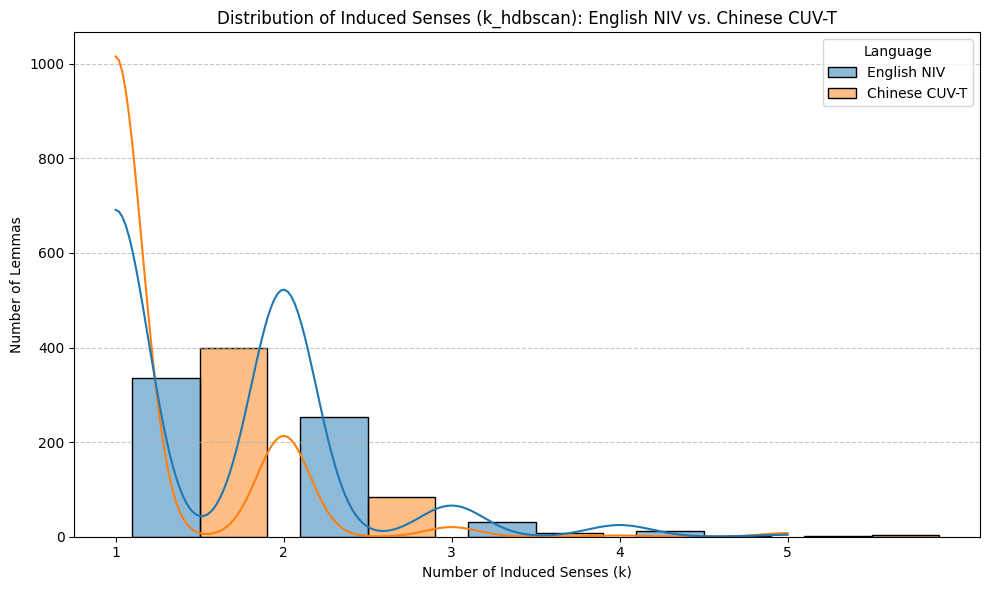

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

# Configuration
DATA_DIR = Path("/content") / "bible_data"
OUTPUT_DIR = Path("/content") / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"

# Load 'en' and 'zh' dataframes
en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Combine the k_hdbscan values from both dataframes into a single DataFrame
combined_k_hdbscan = pd.concat([
    en[['k_hdbscan']].assign(Language='English NIV'),
    zh[['k_hdbscan']].assign(Language='Chinese CUV-T')
])

plt.figure(figsize=(10, 6))
sns.histplot(
    data=combined_k_hdbscan,
    x='k_hdbscan',
    hue='Language',
    multiple='dodge', # Plots bars side-by-side
    shrink=0.8,       # Narrows the bars slightly for better separation
    # kde=True,         # Adds a Kernel Density Estimate line
    kde=True,         # Adds a Kernel Density Estimate line
    bins=range(1, int(combined_k_hdbscan['k_hdbscan'].max()) + 2) # Ensures bins are centered on integers
)

plt.title('Distribution of Induced Senses (k_hdbscan): English NIV vs. Chinese CUV-T')
plt.xlabel('Number of Induced Senses (k)')
plt.ylabel('Number of Lemmas')
plt.xticks(range(1, int(combined_k_hdbscan['k_hdbscan'].max()) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot to the output directory if it's defined
if 'OUTPUT_DIR' in locals() or 'OUTPUT_DIR' in globals():
    plot_filename = OUTPUT_DIR / "figures" / "k_hdbscan_distribution_en_zh.png"
    plt.savefig(plot_filename, dpi=300)
    print(f"Saved plot to {plot_filename}")
else:
    print("OUTPUT_DIR not defined. Plot not saved to file.")

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from umap import UMAP

# Configuration
DATA_DIR = Path("/content") / "bible_data"
OUTPUT_DIR = Path("/content") / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"

# Load data
embeddings_data = np.load(DATA_DIR / "chinese_embeddings.npz", allow_pickle=True)
zho_sense_labels = pd.read_csv(DATA_DIR / "chinese_sense_labels.csv")
zho_nouns = pd.read_csv(DATA_DIR / "chinese_nouns.csv")

# Filter for the lemma '人'
lemma_to_analyze = '人'

# Get original embeddings and metadata for '人'
mask = (embeddings_data['lemmas'] == lemma_to_analyze)
lemma_embeddings = embeddings_data['embeddings'][mask]
lemma_verse_ids = embeddings_data['verse_ids'][mask]
lemma_tokens = embeddings_data['tokens'][mask]

# Directly get lemma_labels using the same mask, as zho_sense_labels is aligned by occurrence
lemma_labels = zho_sense_labels[mask]['cluster_hdbscan'].values


print(f"Analyzing lemma: '{lemma_to_analyze}'")
print(f"Number of occurrences: {len(lemma_embeddings)}")
print(f"Number of clusters (excluding noise): {len(np.unique(lemma_labels[lemma_labels != -1]))}")

# Dimensionality Reduction (UMAP for visualization)
reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
lemma_embeddings_2d = reducer.fit_transform(lemma_embeddings)

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'x': lemma_embeddings_2d[:, 0],
    'y': lemma_embeddings_2d[:, 1],
    'cluster': lemma_labels,
    'verse_id': lemma_verse_ids,
    'token': lemma_tokens
})

# Merge with original nouns_df to get context
plot_df = plot_df.merge(zho_nouns[['verse_id', 'context']], on='verse_id', how='left').drop_duplicates(subset=['x', 'y', 'cluster'])

# Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='x',
    y='y',
    hue='cluster',
    palette='viridis' if len(np.unique(lemma_labels)) > 1 else ['grey'], # Use viridis for multiple clusters, grey for one
    data=plot_df,
    s=50, # size of points
    alpha=0.7,
    legend='full'
)
plt.title(f"UMAP Visualization of Contextual Embeddings for '{lemma_to_analyze}' (Chinese)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plot_filename = FIGURES_DIR / f"umap_clusters_{lemma_to_analyze}_chinese.png"
plt.savefig(plot_filename, dpi=300)
print(f"Saved UMAP plot to {plot_filename}")
plt.show()


# --- Qualitative Examples for each cluster ---
print(f"\n--- Qualitative Examples for '{lemma_to_analyze}' Clusters ---")
for cluster_id in sorted(plot_df['cluster'].unique()):
    if cluster_id == -1:
        print(f"\nCluster -1 (Noise/Outliers):")
    else:
        print(f"\nCluster {cluster_id}:")

    cluster_examples = plot_df[plot_df['cluster'] == cluster_id].sample(min(3, len(plot_df[plot_df['cluster'] == cluster_id])), random_state=42)
    for _, row in cluster_examples.iterrows():
        print(f"  - Verse {row['verse_id']}: {row['context'][:100]}...")

FileNotFoundError: [Errno 2] No such file or directory: '/content/bible_data/chinese_embeddings.npz'

In [ ]:
results = pd.read_csv("/content/bible_data/chinese_wsi_results.csv")
polysemous = results[results['k_hdbscan'] > 1].sort_values('n_instances', ascending=False)
print(polysemous[['lemma', 'n_instances', 'k_hdbscan']].head(20))

    lemma  n_instances  k_hdbscan
10      人         9247          2
85      地         1396          2
320    祭司          857          2
299    百姓          827          2
162    弟兄          695          2
93      城          692          2
308    眾人          664          2
240     殿          480          2
131    子孫          429          5
192    支派          374          2
459    門徒          335          2
128    婦人          314          3
481    首領          276          3
104     壇          267          3
350    罪孽          241          2
36     兒女          235          2
310    眾民          224          2
178    惡人          222          2
279     物          210          2
398     處          209          3


In [ ]:
lemmas_with_ren = results[results['lemma'].str.contains('人')].sort_values(by='n_instances', ascending=False)
display(lemmas_with_ren)

,lemma,n_instances,k_hdbscan
10,人,9247,2
29,僕人,683,1
308,眾人,664,2
128,婦人,314,3
178,惡人,222,2
8,主人,182,2
359,義人,167,2
197,敵人,131,1
147,少年人,130,1
5,世人,119,1


In [ ]:
from IPython.display import Image, display
from pathlib import Path

# Assuming OUTPUT_DIR is defined and the filename convention
OUTPUT_DIR = Path("/content") / "output"
lemma_to_analyze = '人'
plot_filename = OUTPUT_DIR / "figures" / f"umap_clusters_{lemma_to_analyze}_chinese.png"

if plot_filename.exists():
    print(f"Displaying: {plot_filename}")
    display(Image(filename=plot_filename))
else:
    print(f"Plot file not found at {plot_filename}")

Plot file not found at /content/output/figures/umap_clusters_人_chinese.png


### Identifying English Words with Multiple Chinese Translations

### Inspecting POS Tags for 'burnt' and 'offering'

In [ ]:
import spacy
import pandas as pd
from pathlib import Path

# Load the spaCy English model
nlp = spacy.load("en_core_web_sm", disable=["ner", "textcat"])

# Define the DATA_DIR if not already defined
if 'DATA_DIR' not in globals():
    DATA_DIR = Path("/content") / "bible_data"

# Load the English verses to find contexts for 'burnt offering'
en_verses_df = pd.read_csv(DATA_DIR / "english_verses.csv")

# Filter for verses containing 'burnt offering'
burnt_offering_verses = en_verses_df[en_verses_df['text'].str.contains('burnt offering', case=False, na=False)]

print(f"Found {len(burnt_offering_verses)} verses containing 'burnt offering'.")

# Process and display POS tags for a few examples
for i, row in burnt_offering_verses.head(5).iterrows(): # Limiting to 5 examples for brevity
    verse_id = row['verse_id']
    text = row['text']
    doc = nlp(text)

    print(f"\n--- Verse ID: {verse_id} ---")
    print(f"Original text: {text}")
    print("Token | Lemma | POS_Tag | Dependency | Head | Head_POS")
    print("-----------------------------------------------------------")
    for token in doc:
        print(f"{token.text:<5} | {token.lemma_:<5} | {token.pos_:<7} | {token.dep_:<10} | {token.head.text:<4} | {token.head.pos_}")


Found 255 verses containing 'burnt offering'.

--- Verse ID: Gen.8.20 ---
Original text: Then Noah built an altar to the LORD and, taking some of all the clean animals and clean birds, he sacrificed burnt offerings on it.
Token | Lemma | POS_Tag | Dependency | Head | Head_POS
-----------------------------------------------------------
Then  | then  | ADV     | advmod     | built | VERB
Noah  | Noah  | PROPN   | nsubj      | built | VERB
built | build | VERB    | ccomp      | sacrificed | VERB
an    | an    | DET     | det        | altar | NOUN
altar | altar | NOUN    | dobj       | built | VERB
to    | to    | ADP     | dative     | built | VERB
the   | the   | DET     | det        | LORD | PROPN
LORD  | LORD  | PROPN   | pobj       | to   | ADP
and   | and   | CCONJ   | cc         | built | VERB
,     | ,     | PUNCT   | punct      | built | VERB
taking | take  | VERB    | advcl      | built | VERB
some  | some  | PRON    | dobj       | taking | VERB
of    | of    | ADP     | prep    

In [ ]:
import pandas as pd
from pathlib import Path

# Assuming DATA_DIR is defined from previous cells
DATA_DIR = Path('/content') / 'bible_data'

# Load English and Chinese noun data
en_nouns = pd.read_csv(DATA_DIR / 'english_nouns.csv')
zh_nouns = pd.read_csv(DATA_DIR / 'chinese_nouns.csv')

print(f"Loaded {len(en_nouns):,} English noun occurrences.")
print(f"Loaded {len(zh_nouns):,} Chinese noun occurrences.")

# Rename columns for clarity before merging
en_nouns_renamed = en_nouns[['verse_id', 'lemma']].rename(columns={'lemma': 'english_lemma'})
zh_nouns_renamed = zh_nouns[['verse_id', 'lemma']].rename(columns={'lemma': 'chinese_lemma'})

# Merge dataframes on verse_id
# We use an inner join to only keep verses present in both datasets
merged_df = pd.merge(en_nouns_renamed, zh_nouns_renamed, on='verse_id', how='inner')

print(f"Merged dataframe contains {len(merged_df):,} co-occurrences in the same verse.")
display(merged_df.head())

Loaded 98,195 English noun occurrences.
Loaded 68,932 Chinese noun occurrences.
Merged dataframe contains 278,207 co-occurrences in the same verse.


,verse_id,english_lemma,chinese_lemma
0,Gen.1.1,beginning,天地
1,Gen.1.1,heaven,天地
2,Gen.1.1,earth,天地
3,Gen.1.2,earth,地
4,Gen.1.2,darkness,地


In [ ]:
# Group by English lemma and count unique Chinese lemmas
english_to_chinese_map = merged_df.groupby('english_lemma')['chinese_lemma'].nunique().reset_index(name='num_unique_chinese_translations')

# Sort to find English lemmas with the most unique Chinese translations
english_to_chinese_map = english_to_chinese_map.sort_values(by='num_unique_chinese_translations', ascending=False)

print("Top English lemmas with multiple Chinese translations:")
display(english_to_chinese_map.head(20))

Top English lemmas with multiple Chinese translations:


,english_lemma,num_unique_chinese_translations
322,man,489
385,people,454
131,day,444
248,hand,408
288,king,404
513,son,402
297,land,383
563,time,369
392,place,365
270,house,362


The table above shows English lemmas ranked by the number of unique Chinese lemmas they co-occur with within the same verses. A higher count suggests that the English word might have several distinct ways of being translated or conveyed in Chinese, reflecting semantic breadth or cultural differences in expression.

Let's pick one of the top English lemmas and look at some of the Chinese lemmas it co-occurs with as examples.

In [ ]:
# Choose a top English lemma for example
example_english_lemma = english_to_chinese_map.iloc[0]['english_lemma'] # Takes the top one

print(f"Examples of Chinese translations for the English lemma: '{example_english_lemma}'")

# Get all unique Chinese lemmas associated with this English lemma
chinese_translations = merged_df[merged_df['english_lemma'] == example_english_lemma]['chinese_lemma'].unique()

# Display the unique Chinese translations
for i, zh_lemma in enumerate(chinese_translations[:10]): # Display up to 10 examples
    print(f"- {zh_lemma}")

# Optionally, display some actual verse examples
print(f"\nSome verse examples where '{example_english_lemma}' co-occurs with different Chinese lemmas:")
example_verses = merged_df[merged_df['english_lemma'] == example_english_lemma].drop_duplicates(subset=['chinese_lemma']).head(5)

for _, row in example_verses.iterrows():
    print(f"- Verse ID: {row['verse_id']} | English: '{row['english_lemma']}' | Chinese: '{row['chinese_lemma']}'")

Examples of Chinese translations for the English lemma: 'man'
- 樣式
- 魚
- 鳥
- 地上
- 牲畜
- 全地
- 野地
- 田間
- 人
- 氣

Some verse examples where 'man' co-occurs with different Chinese lemmas:
- Verse ID: Gen.1.26 | English: 'man' | Chinese: '樣式'
- Verse ID: Gen.1.26 | English: 'man' | Chinese: '魚'
- Verse ID: Gen.1.26 | English: 'man' | Chinese: '鳥'
- Verse ID: Gen.1.26 | English: 'man' | Chinese: '地上'
- Verse ID: Gen.1.26 | English: 'man' | Chinese: '牲畜'


In [ ]:
example_english_lemma_people = 'people'

print(f"Examples of Chinese translations for the English lemma: '{example_english_lemma_people}'")

# Get all unique Chinese lemmas associated with this English lemma
chinese_translations_people = merged_df[merged_df['english_lemma'] == example_english_lemma_people]['chinese_lemma'].unique()

# Display the unique Chinese translations
for i, zh_lemma in enumerate(chinese_translations_people[:10]): # Display up to 10 examples
    print(f"- {zh_lemma}")

# Optionally, display some actual verse examples
print(f"\nSome verse examples where '{example_english_lemma_people}' co-occurs with different Chinese lemmas:")
example_verses_people = merged_df[merged_df['english_lemma'] == example_english_lemma_people].drop_duplicates(subset=['chinese_lemma']).head(5)

for _, row in example_verses_people.iterrows():
    print(f"- Verse ID: {row['verse_id']} | English: '{row['english_lemma']}' | Chinese: '{row['chinese_lemma']}'")

Examples of Chinese translations for the English lemma: 'people'
- 代
- 義人
- 人
- 世界
- 血氣
- 地上
- 兒子
- 全地
- 地土
- 方言

Some verse examples where 'people' co-occurs with different Chinese lemmas:
- Verse ID: Gen.6.9 | English: 'people' | Chinese: '代'
- Verse ID: Gen.6.9 | English: 'people' | Chinese: '義人'
- Verse ID: Gen.6.9 | English: 'people' | Chinese: '人'
- Verse ID: Gen.6.12 | English: 'people' | Chinese: '世界'
- Verse ID: Gen.6.12 | English: 'people' | Chinese: '血氣'


In [ ]:
import pandas as pd

# Load WSI results
df_zh = pd.read_csv("bible_data/chinese_wsi_results.csv")

# Sort by polysemy to inspect high-k words
high_k = df_zh[df_zh['k_hdbscan'] >= 2].sort_values('k_hdbscan', ascending=False)

print(f"Found {len(high_k)} polysemous words")
print("\nTop 30 polysemous words to inspect:")
print(high_k[['lemma', 'n_instances', 'k_hdbscan']].head(30))

# Check for suspicious patterns
suspicious = []

for idx, row in high_k.iterrows():
    lemma = row['lemma']
    flags = []

    # Flag 1: Contains common verb characters
    verb_chars = '說來去作使見知行得成為給立取求呼問答聽';
    if any(c in lemma for c in verb_chars):
        flags.append("VERB_CHAR")

    # Flag 2: Starts with 主 (Lord) - might be "Lord + verb"
    if lemma.startswith('主') and len(lemma) > 1:
        flags.append("主+X")

    # Flag 3: Starts with common proper name prefixes
    proper_prefixes = '亞以所耶撒利摩迦法馬雅巴該西拉';
    if lemma[0] in proper_prefixes and len(lemma) == 2:
        flags.append("PROPER_FRAGMENT?")

    # Flag 4: Very short (2 chars) with high k - suspicious
    if len(lemma) == 2 and row['k_hdbscan'] >= 3:
        flags.append("SHORT+HIGH_K")

    if flags:
        suspicious.append({
            'lemma': lemma,
            'n': row['n_instances'],
            'k': row['k_hdbscan'],
            'flags': ', '.join(flags)
        })

df_suspicious = pd.DataFrame(suspicious)
print(f"\n{len(df_suspicious)} suspicious lemmas flagged:")
print(df_suspicious.to_string(index=False))

# Save for manual review
df_suspicious.to_csv("bible_data/suspicious_lemmas_to_review.csv", index=False)
print("\nSaved to: suspicious_lemmas_to_review.csv")

Found 96 polysemous words

Top 30 polysemous words to inspect:
    lemma  n_instances  k_hdbscan
131    子孫          429          5
441    郊野          117          5
388   舍客勒          128          5
319     祭          112          4
134    孩子          203          3
24     供物           98          3
104     壇          267          3
128    婦人          314          3
206     時          166          3
481    首領          276          3
398     處          209          3
378    脂油           91          3
42      公           56          2
1      下體           41          2
10      人         9247          2
8      主人          182          2
63      口           69          2
61    十字架           83          2
52     凡事           79          2
49     兵器           75          2
93      城          692          2
75      嘴           77          2
85      地         1396          2
77     器具           64          2
111    天使          173          2
43     公平           88          2
45     公羊          

As you can see, for `lemma_length = 2`, the number of *unique lemmas* is around 6,000, which aligns with your earlier observation. The previous plot (and the 'Top 10 Chinese Lemmas by Character Length' table) showed the *sum of all occurrences* for lemmas of a given length, which is a different metric.

Let me know if you would like me to generate a plot for the 'number of unique lemmas' distribution, or if you have any other questions!

Saved plot to /content/output/figures/chinese_unique_lemma_length_distribution.png


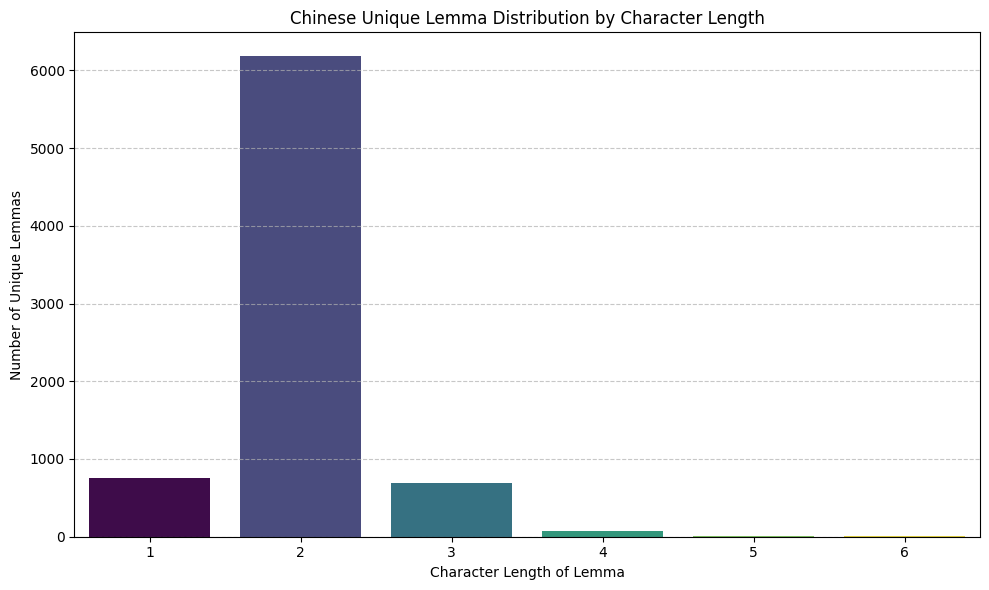

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='lemma_length', y='num_unique_lemmas', hue='lemma_length', data=num_unique_lemmas_by_length, palette='viridis', legend=False)

plt.title('Chinese Unique Lemma Distribution by Character Length')
plt.xlabel('Character Length of Lemma')
plt.ylabel('Number of Unique Lemmas')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_filename_unique = FIGURES_DIR / "chinese_unique_lemma_length_distribution.png"
plt.savefig(plot_filename_unique, dpi=300)
print(f"Saved plot to {plot_filename_unique}")

plt.show()

In [ ]:
# Calculate unique lemmas by length for *analyzed* lemmas
num_unique_analyzed_lemmas_by_length = zh_freq_analyzed.groupby('lemma_length').size().reset_index(name='num_unique_lemmas')

display(num_unique_analyzed_lemmas_by_length)

,lemma_length,num_unique_lemmas
0,1,172
1,2,341
2,3,5
3,4,1


And here is the plot visualizing this distribution for the analyzed lemmas:

Saved plot to /content/output/figures/chinese_unique_analyzed_lemma_length_distribution.png


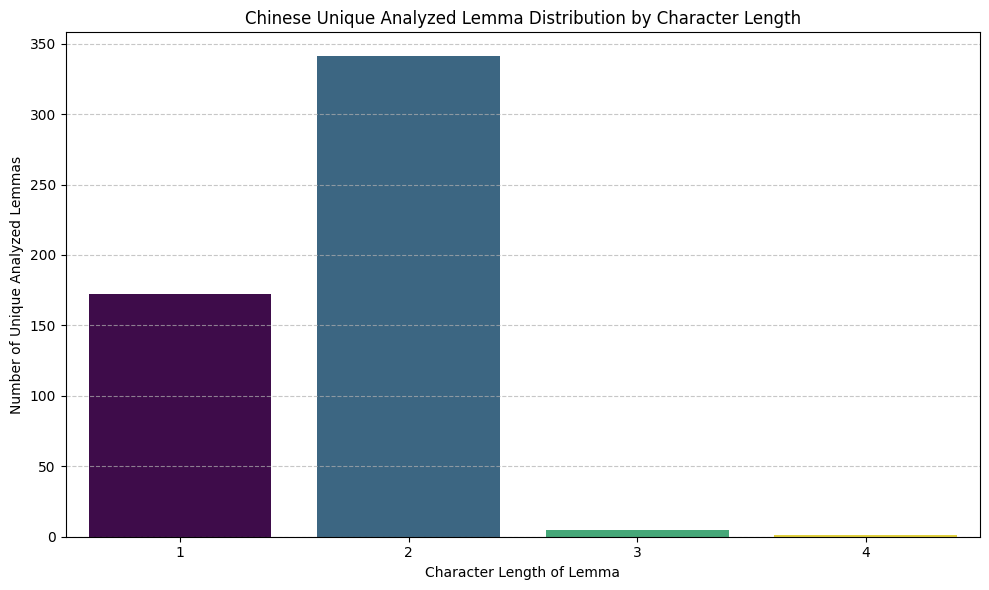

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='lemma_length', y='num_unique_lemmas', hue='lemma_length', data=num_unique_analyzed_lemmas_by_length, palette='viridis', legend=False)

plt.title('Chinese Unique Analyzed Lemma Distribution by Character Length')
plt.xlabel('Character Length of Lemma')
plt.ylabel('Number of Unique Analyzed Lemmas')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_filename_unique_analyzed = FIGURES_DIR / "chinese_unique_analyzed_lemma_length_distribution.png"
plt.savefig(plot_filename_unique_analyzed, dpi=300)
print(f"Saved plot to {plot_filename_unique_analyzed}")

plt.show()

### Top 20 Most Frequent Analyzed Chinese Lemmas (WSI Processed)

In [ ]:
display(zh_freq_analyzed.sort_values(by='count', ascending=False).head(20))

,lemma,count,lemma_length
0,人,9246,1
1,兒子,2358,2
2,事,1553,1
3,話,1497,1
4,地,1396,1
5,時候,1340,2
6,祭司,857,2
7,百姓,827,2
8,弟兄,695,2
9,城,692,1


As you can see, lemmas like '人', '兒子', '事', '話', '地', '時候', and '祭司' are all present in this list, confirming they were indeed part of the WSI and clustering process. They are among the most frequent words in the subset of lemmas that met the minimum frequency threshold for analysis.

This table shows the individual characters that appear most frequently within the multi-character lemmas from our analyzed set. The `total_participation_count` indicates the sum of frequencies of all multi-character lemmas that contain that specific character.

We can see that '人' (person/people) is indeed a highly productive character, appearing often within longer compounds, just as it is a very frequent standalone lemma. The count of 9246 (or 9247) that you observed earlier refers to the overall occurrences of the lemma '人' itself, not its aggregated participation within compounds, which this new table illustrates. The 'total_participation_count' for '人' here specifically reflects its presence *inside* multi-character lemmas.

In [ ]:
from collections import Counter

# Filter for multi-character lemmas from the *full* frequency set
multi_char_lemmas_full = zh_freq[zh_freq['lemma_length'] > 1]

# Initialize a Counter to store character frequencies in multi-character lemmas
char_in_compound_freq_full = Counter()

# Iterate through each multi-character lemma and its frequency
for _, row in multi_char_lemmas_full.iterrows():
    lemma = row['lemma']
    lemma_count = row['count']
    # For each character in the lemma, add its count (based on the lemma's frequency)
    for char in lemma:
        char_in_compound_freq_full[char] += lemma_count

print("\n--- Top 20 Most Productive Characters in All Multi-Character Noun Compounds (Full Dataset) ---")
# Convert to DataFrame for better display and sort
char_compound_df_full = pd.DataFrame(char_in_compound_freq_full.items(), columns=['character', 'total_participation_count'])
char_compound_df_full = char_compound_df_full.sort_values(by='total_participation_count', ascending=False)
display(char_compound_df_full.head(20))


--- Top 20 Most Productive Characters in All Multi-Character Noun Compounds (Full Dataset) ---


,character,total_participation_count
1,子,6699
11,人,4554
0,兒,2992
16,地,2036
3,候,1465
12,眾,1405
2,時,1371
31,女,1323
4,祭,1082
39,民,970


In [ ]:
print(f"Frequency of 'offering' before MWE processing: {en_freq[en_freq['lemma'] == 'offering']['count'].iloc[0]}")
print(f"Frequency of 'offering' after MWE processing: {en_freq_mwe[en_freq_mwe['lemma'] == 'offering']['count'].iloc[0]}")
print(f"Frequency of 'burn_offering' after MWE processing: {en_freq_mwe[en_freq_mwe['lemma'] == 'burn_offering']['count'].iloc[0]}")

Frequency of 'offering' before MWE processing: 1026
Frequency of 'offering' after MWE processing: 254
Frequency of 'burn_offering' after MWE processing: 274


As you can see, the list of top characters and their `total_participation_count` has indeed changed when we consider all multi-character noun compounds from the full `zh_freq` dataset. While some highly productive characters remain at the top (like '子' and '人'), their counts are generally higher, and the ranking of other characters might have shifted due to the inclusion of many more lower-frequency lemmas that were not part of the WSI analysis. This highlights the difference between analyzing the full corpus versus a filtered subset designed for specific WSI tasks.

In [ ]:
print('--- Identifying Filtered-out Single-Word Lemmas ---')

# 1. Get the set of single-word lemmas that met MIN_FREQ before MWE processing
#    This needs to be calculated from the original raw noun occurrences (en_raw)
#    before any MWE processing and before frequency filtering specific to MWE-aware data.
#    We re-apply MIN_FREQ to this raw count to get the *true* 'before' set.
temp_en_raw_freq = en_raw.groupby('lemma').size().reset_index(name='count')
lemmas_before_mwe_processing = set(temp_en_raw_freq[temp_en_raw_freq['count'] >= MIN_FREQ]['lemma'])

# 2. Get the set of single-word lemmas that met MIN_FREQ after MWE processing
#    First, identify actual MWEs that were formed AND passed the final MIN_FREQ filter for WSI.
mwes_that_passed_filter = set(mwes_df['mwe']).intersection(set(en_filtered_mwe['lemma']))

#    Then, get all lemmas from the final MWE-aware filtered list (which includes both single-words and MWEs)
all_lemmas_after_mwe_processing = set(en_filtered_mwe['lemma'])

#    Remove the actual MWEs (that passed the final filter) to get only the single-word lemmas remaining after MWE processing
single_word_lemmas_after_mwe_processing = all_lemmas_after_mwe_processing - mwes_that_passed_filter

# 3. Find the difference: lemmas present (and meeting MIN_FREQ) before MWE processing
#    but not present (or fell below MIN_FREQ, or were absorbed into an MWE) after MWE processing
filtered_out_lemmas = sorted(list(lemmas_before_mwe_processing - single_word_lemmas_after_mwe_processing))

print(f"Total unique single-word lemmas that passed MIN_FREQ before MWE processing: {len(lemmas_before_mwe_processing)}")
print(f"Total unique single-word lemmas (excluding MWEs) that passed MIN_FREQ after MWE processing: {len(single_word_lemmas_after_mwe_processing)}")
print(f"Number of single-word lemmas filtered out (or absorbed into MWEs, or fell below MIN_FREQ): {len(filtered_out_lemmas)}")

print('\nThese are the lemmas that were effectively \'lost\' from the single-word lemma count after MWE processing:')
display(pd.DataFrame(filtered_out_lemmas, columns=['Filtered Out Lemma']))

--- Identifying Filtered-out Single-Word Lemmas ---
Total unique single-word lemmas that passed MIN_FREQ before MWE processing: 636
Total unique single-word lemmas (excluding MWEs) that passed MIN_FREQ after MWE processing: 610
Number of single-word lemmas filtered out (or absorbed into MWEs, or fell below MIN_FREQ): 26

These are the lemmas that were effectively 'lost' from the single-word lemma count after MWE processing:


,Filtered Out Lemma
0,aroma
1,choice
2,citizen
3,cloth
4,conscience
5,cord
6,countryman
7,cow
8,dish
9,fellow


### Instances of Filtered-out Lemmas Before and After MWE Processing

Below are the occurrences of the lemmas that were filtered out, shown before and after Multi-Word Expression (MWE) processing. This helps visualize how their instances were either absorbed into MWEs or reduced below the `MIN_FREQ` threshold.

In [ ]:
print('--- Instances Before MWE Processing ---')
print('This shows all occurrences of the lemmas before any MWEs were formed and frequency filtering was applied to the MWE-aware list.')

df_before_mwe = en_raw[en_raw['lemma'].isin(filtered_out_lemmas)]
display(df_before_mwe)

--- Instances Before MWE Processing ---
This shows all occurrences of the lemmas before any MWEs were formed and frequency filtering was applied to the MWE-aware list.


,verse_id,token,lemma,context
1389,Gen.15.9,pigeon,pigeon,"So the LORD said to him, ""Bring me a heifer, a..."
4317,Gen.41.42,signet,signet,Then Pharaoh took his signet ring from his fin...
8387,Exod.28.11,filigree,filigree,Engrave the names of the sons of Israel on the...
8398,Exod.28.13,filigree,filigree,Make gold filigree settings
8434,Exod.28.20,filigree,filigree,"in the fourth row a chrysolite, an onyx and a ..."
10134,Exod.39.13,filigree,filigree,"in the fourth row a chrysolite, an onyx and a ..."
10508,Lev.1.14,pigeon,pigeon,"""'If the offering to the LORD is a burnt offer..."
10971,Lev.5.7,pigeons,pigeon,"""'If he cannot afford a lamb, he is to bring t..."
10998,Lev.5.11,pigeons,pigeon,"""'If, however, he cannot afford two doves or t..."
12006,Lev.12.6,pigeon,pigeon,"""'When the days of her purification for a son ..."


In [ ]:
print('--- Instances After MWE Processing ---')
print('This shows occurrences of the same lemmas after MWEs were formed. Notice that some instances might be missing if they became part of an MWE, or the lemma might be absent entirely if its frequency dropped below MIN_FREQ and it was filtered out.')

df_after_mwe = en_raw_mwe[en_raw_mwe['lemma'].isin(filtered_out_lemmas)]
display(df_after_mwe)

--- Instances After MWE Processing ---
This shows occurrences of the same lemmas after MWEs were formed. Notice that some instances might be missing if they became part of an MWE, or the lemma might be absent entirely if its frequency dropped below MIN_FREQ and it was filtered out.


,verse_id,token,lemma,context


In [ ]:
print('--- Instance Counts Before MWE Processing ---')
lemma_counts_before = en_raw[en_raw['lemma'].isin(filtered_out_lemmas)].groupby('lemma').size().reset_index(name='count_before_mwe')
display(lemma_counts_before)

print('\n--- Instance Counts After MWE Processing ---')
# Filter en_raw_mwe to include only lemmas that are in filtered_out_lemmas
# And ensure that these are *single words* (i.e., not MWEs themselves)
# This is already handled by how filtered_out_lemmas is defined (lemmas_before_mwe_processing - single_word_lemmas_after_mwe_processing)
# However, we must explicitly check the 'lemma' column in en_raw_mwe to see if any instances of these *original* lemmas remain.
lemma_counts_after = en_raw_mwe[en_raw_mwe['lemma'].isin(filtered_out_lemmas)].groupby('lemma').size().reset_index(name='count_after_mwe')
display(lemma_counts_after)

print('\n--- Comparison of Counts ---')
comparison_df = pd.merge(lemma_counts_before, lemma_counts_after, on='lemma', how='left').fillna(0)
comparison_df['count_after_mwe'] = comparison_df['count_after_mwe'].astype(int)
display(comparison_df)

--- Instance Counts Before MWE Processing ---


,lemma,count_before_mwe
0,aroma,41
1,choice,34
2,citizen,32
3,cloth,30
4,conscience,35
5,cord,32
6,countryman,30
7,cow,38
8,dish,37
9,fellow,32



--- Instance Counts After MWE Processing ---


,lemma,count_after_mwe
0,aroma,28
1,choice,29
2,citizen,25
3,cloth,24
4,conscience,29
5,cord,27
6,countryman,24
7,cow,25
8,dish,20
9,fellow,29



--- Comparison of Counts ---


,lemma,count_before_mwe,count_after_mwe
0,aroma,41,28
1,choice,34,29
2,citizen,32,25
3,cloth,30,24
4,conscience,35,29
5,cord,32,27
6,countryman,30,24
7,cow,38,25
8,dish,37,20
9,fellow,32,29
